# Financial Health Prediction — Exploratory Data Analysis

Comprehensive research notebook for the MSME Financial Health dataset. All figures are saved under `eda/figures/` with descriptive filenames for reports and presentations.

**Contents:** data quality, target balance, univariate and bivariate analysis, association tests (chi-square, Cramér's V, mutual information), engineered features, baseline models, ROC-AUC (one-vs-rest), confusion matrices, and feature importance.

---

## 1. Environment, paths, and plotting defaults

Charts are saved under `eda/figures/` only when missing. Existing PNGs are reused (not deleted). Each chart is shown inline in the notebook and listed again in the figure gallery at the end.

In [1]:
%matplotlib inline
import os
import warnings
from pathlib import Path

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    accuracy_score,
    auc,
    roc_curve,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import LabelEncoder, label_binarize

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["font.size"] = 10

# Resolve project root (notebook may run from eda/ or project root)
BASE_PATH = Path.cwd()
for candidate in [BASE_PATH, BASE_PATH.parent, BASE_PATH / ".."]:
    p = candidate.resolve()
    if (p / "datasets" / "Train.csv").is_file():
        BASE_PATH = p
        break
else:
    raise FileNotFoundError(
        "Could not find datasets/Train.csv. Run from financial-prediction-model/ or eda/."
    )

DATASETS = BASE_PATH / "datasets"
FIGURES = (BASE_PATH / "eda" / "figures").resolve()
FINDINGS_PATH = (BASE_PATH / "eda" / "decision_parameters_summary.csv").resolve()
VAR_DEF_PATH = DATASETS / "VariableDefinitions.csv"
TRAIN_PATH = DATASETS / "Train.csv"
TEST_PATH = DATASETS / "Test.csv"

TARGET_MAP = {"Low": 0, "Medium": 1, "High": 2}
CLASS_NAMES = ["Low", "Medium", "High"]
RANDOM_STATE = 42

EXPECTED_FIGURES = (
    "01_missing_value_pattern_sample500.png",
    "02_target_distribution_counts_and_percent.png",
    "03_target_distribution_by_country_stacked.png",
    "04_numeric_feature_distributions_histograms.png",
    "05_numeric_boxplots_by_target.png",
    "06_numeric_correlation_with_target.png",
    "07_numeric_correlation_heatmap.png",
    "08_top_categorical_cramers_v_with_target.png",
    "09_mutual_information_top25.png",
    "10_top_categorical_target_composition_stacked.png",
    "11_insurance_adoption_tier_vs_target.png",
    "12_financial_services_adoption_tier_vs_target.png",
    "13_engineered_features_correlation_heatmap.png",
    "14_engineered_features_boxplots_by_target.png",
    "15_random_forest_feature_importance_top30.png",
    "16_engineered_features_rf_importance_top15.png",
    "17_confusion_matrix_lightgbm_oof.png",
    "18_roc_curves_ovr_lightgbm_oof.png",
    "19_lightgbm_feature_importance_top30.png",
)


FIGURES.mkdir(parents=True, exist_ok=True)


def figure_exists(name):
    path = FIGURES / name
    return path.is_file() and path.stat().st_size > 0


def show_figure(name):
    """Display a saved figure in the notebook."""
    from IPython.display import Image, display

    path = FIGURES / name
    if not path.is_file():
        print(f"Not found (run plot cell first): {name}")
        return
    display(Image(filename=str(path)))


def save_figure(name, tight=True):
    """Save the current plot if missing, then display it (never deletes existing files)."""
    if name not in EXPECTED_FIGURES:
        raise ValueError(f"Unexpected figure name: {name}")
    path = FIGURES / name
    if figure_exists(name):
        plt.close("all")
        print(f"Using cached figure: {name}")
    else:
        if tight:
            plt.tight_layout()
        plt.savefig(path, bbox_inches="tight")
        plt.close("all")
        print(f"Saved: {name}")
    show_figure(name)


cached_figs = sum(figure_exists(n) for n in EXPECTED_FIGURES)
print("BASE_PATH:", BASE_PATH)
print("Figures directory:", FIGURES)
print(f"Cached figures on disk: {cached_figs}/{len(EXPECTED_FIGURES)}")

BASE_PATH: C:\Users\nqobi\Documents\GitHub\financial-prediction\financial-prediction-model
Figures directory: C:\Users\nqobi\Documents\GitHub\financial-prediction\financial-prediction-model\eda\figures
Cached figures on disk: 19/19


## 2. Load data and variable dictionary

In [2]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
var_defs = pd.read_csv(VAR_DEF_PATH)

print("Train:", train.shape, "| Test:", test.shape)
print("\nTarget distribution (%):")
print((train["Target"].value_counts(normalize=True) * 100).round(2))

display(var_defs.head(10))

Train: (9618, 39) | Test: (2405, 38)

Target distribution (%):
Target
Low       65.29
Medium    29.82
High       4.89
Name: proportion, dtype: float64


,VARIABLE_NAME,VARIABLE_DESCRIPTION
0,ID,Unique identifier for each business record
1,country,Country where the business is located (Eswatin...
2,owner_age,Age of the business owner in years
3,attitude_stable_business_environment,Owner attitude: Country will have a stable bus...
4,attitude_worried_shutdown,Owner attitude: Worried that the business will...
5,compliance_income_tax,Business complies with or acts in accordance w...
6,perception_insurance_doesnt_cover_losses,Owner perception: Insurance does not cover the...
7,perception_cannot_afford_insurance,Owner perception: Cannot afford insurance paym...
8,personal_income,Total monthly personal income of the owner bef...
9,business_expenses,Approximate monthly or annual expenses of the ...


## 3. Data overview and quality

,dtype,missing_count,missing_pct,n_unique
uses_informal_lender,object,4489,46.67,6
uses_friends_family_savings,object,4488,46.66,6
motivation_make_more_money,object,4291,44.61,2
funeral_insurance,object,4188,43.54,5
medical_insurance,object,4188,43.54,6
business_age_months,float64,4111,42.74,12
future_risk_theft_stock,object,4100,42.63,2
has_debit_card,object,4003,41.62,5
has_internet_banking,object,4003,41.62,6
has_loan_account,object,3999,41.58,6


Using cached figure: 01_missing_value_pattern_sample500.png


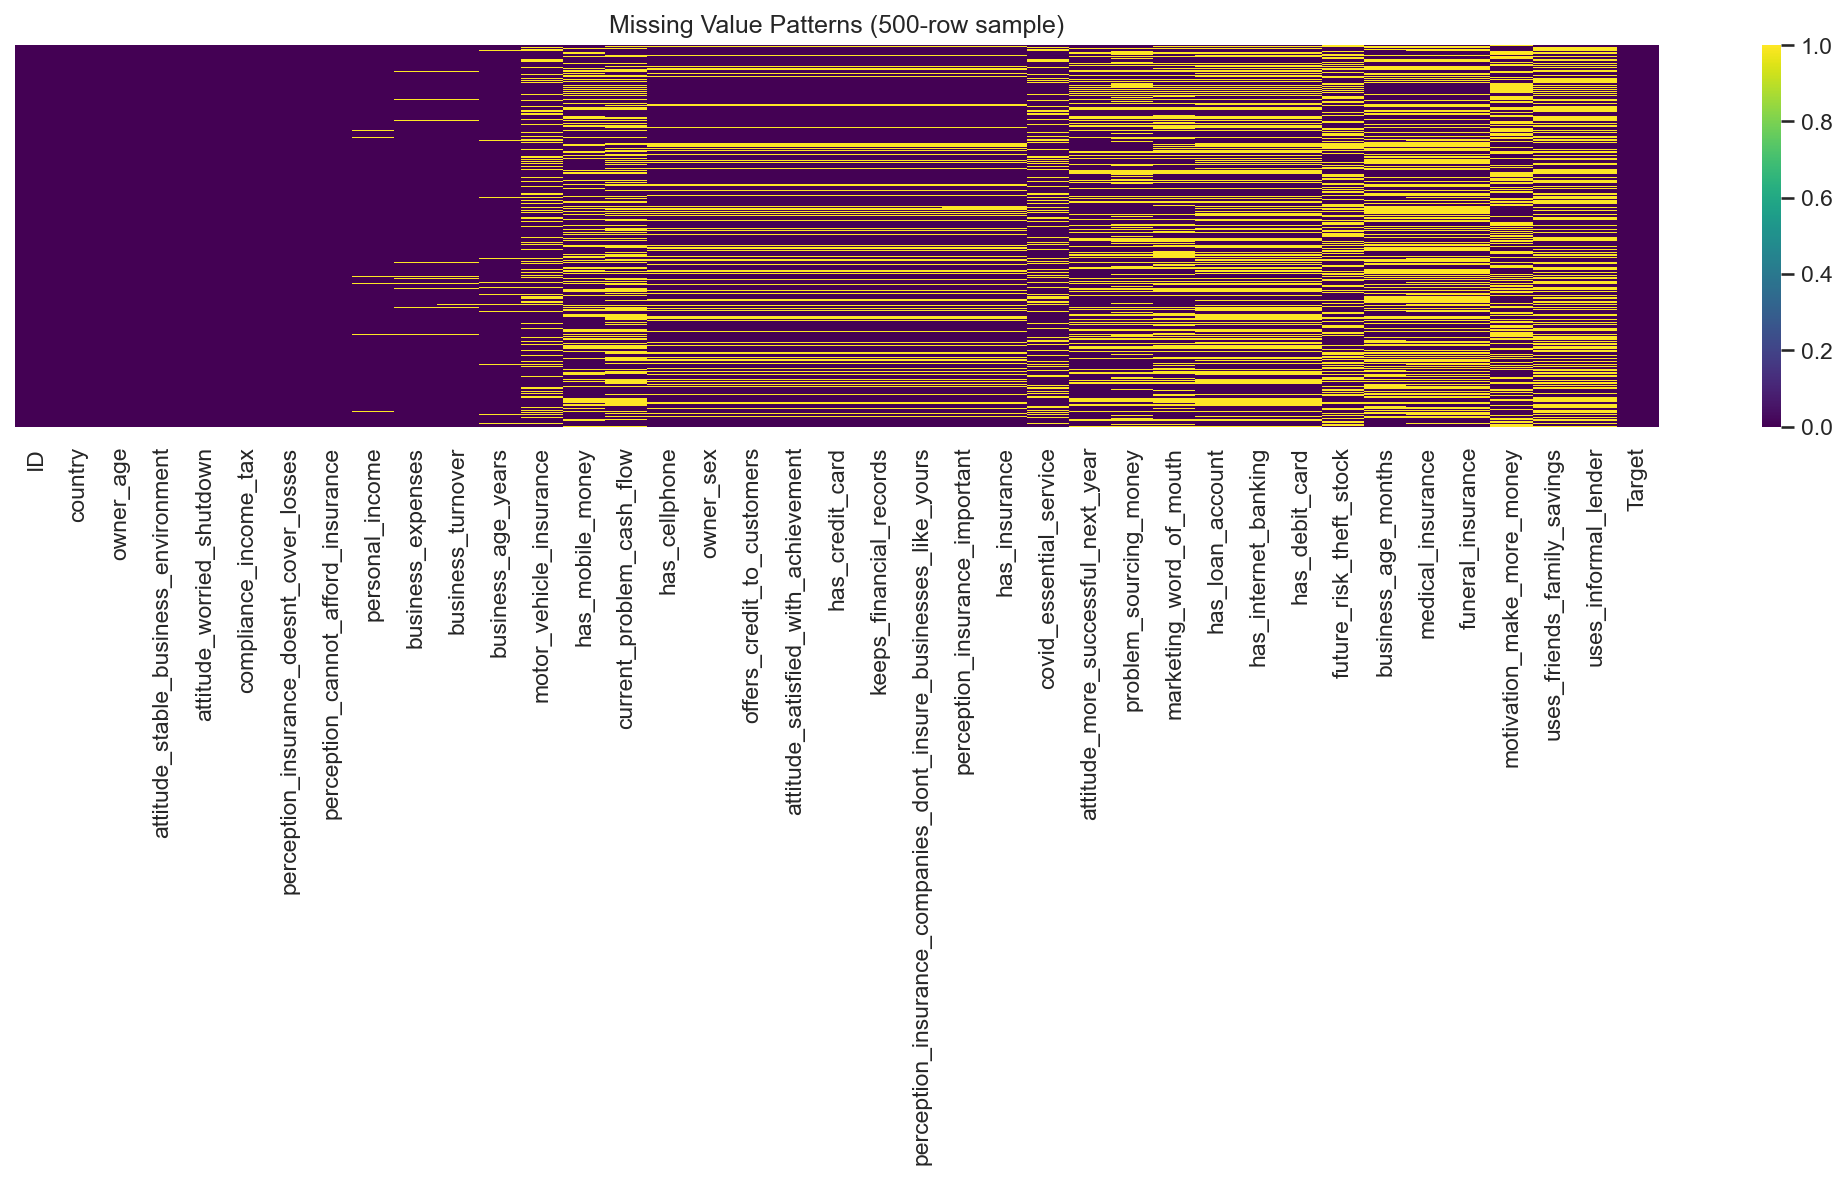

In [3]:
overview = pd.DataFrame({
    "dtype": train.dtypes,
    "missing_count": train.isnull().sum(),
    "missing_pct": (train.isnull().sum() / len(train) * 100).round(2),
    "n_unique": train.nunique(),
})
overview = overview.sort_values("missing_pct", ascending=False)
display(overview.head(20))

# Missingness heatmap (sample of rows for readability)
if not figure_exists("01_missing_value_pattern_sample500.png"):
    sample_idx = np.random.RandomState(RANDOM_STATE).choice(
        len(train), size=min(500, len(train)), replace=False
    )
    miss_matrix = train.iloc[sample_idx].isnull().astype(int)
    plt.figure(figsize=(14, 8))
    sns.heatmap(
        miss_matrix,
        cbar=True,
        cmap="viridis",
        yticklabels=False,
        xticklabels=miss_matrix.columns,
    )
    plt.title("Missing Value Patterns (500-row sample)")
    plt.xticks(rotation=90)
save_figure("01_missing_value_pattern_sample500.png")

## 4. Target distribution and class imbalance

Using cached figure: 02_target_distribution_counts_and_percent.png


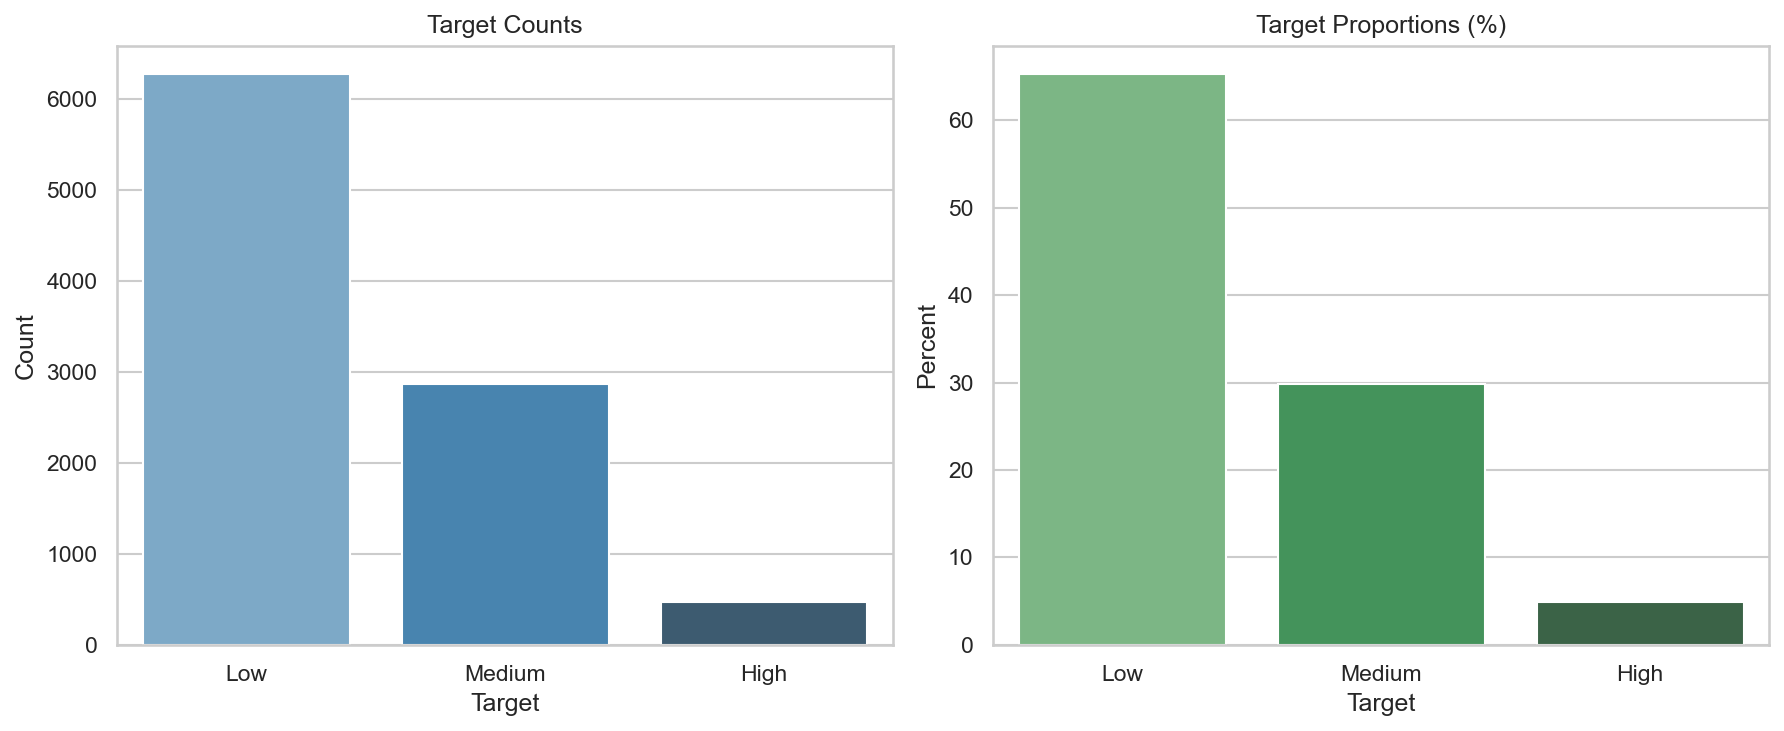

Imbalance ratio (max/min): 13.36


In [4]:
target_counts = train["Target"].value_counts().reindex(CLASS_NAMES)
target_pct = (target_counts / len(train) * 100).round(2)

if not figure_exists("02_target_distribution_counts_and_percent.png"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.barplot(x=target_counts.index, y=target_counts.values, ax=axes[0], palette="Blues_d")
    axes[0].set_title("Target Counts")
    axes[0].set_ylabel("Count")
    sns.barplot(x=target_pct.index, y=target_pct.values, ax=axes[1], palette="Greens_d")
    axes[1].set_title("Target Proportions (%)")
    axes[1].set_ylabel("Percent")
save_figure("02_target_distribution_counts_and_percent.png")

imbalance_ratio = target_counts.max() / target_counts.min()
print(f"Imbalance ratio (max/min): {imbalance_ratio:.2f}")

## 5. Geographic segmentation (country)

Using cached figure: 03_target_distribution_by_country_stacked.png


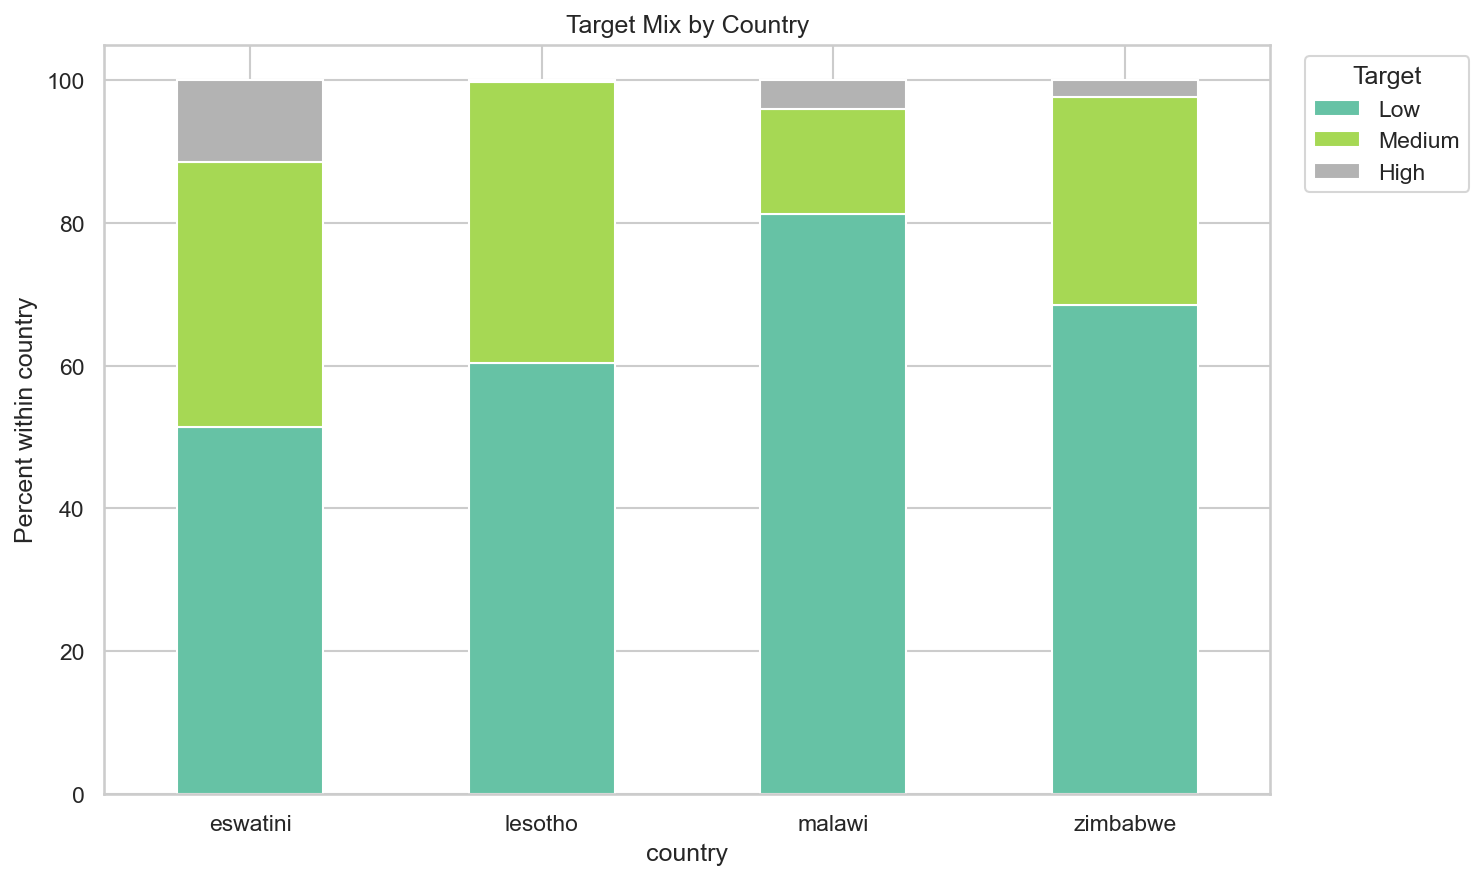

Country vs Target chi2 p-value: 2.18e-176


In [5]:
country_target = pd.crosstab(train["country"], train["Target"], normalize="index") * 100

if not figure_exists("03_target_distribution_by_country_stacked.png"):
    plt.figure(figsize=(10, 6))
    country_target[CLASS_NAMES].plot(kind="bar", stacked=True, colormap="Set2")
    plt.ylabel("Percent within country")
    plt.title("Target Mix by Country")
    plt.legend(title="Target", bbox_to_anchor=(1.02, 1))
    plt.xticks(rotation=0)
save_figure("03_target_distribution_by_country_stacked.png")

chi2, p, _, _ = chi2_contingency(pd.crosstab(train["country"], train["Target"]))
print(f"Country vs Target chi2 p-value: {p:.2e}")

## 6. Numeric features — distributions and target separation

Numeric columns: ['owner_age', 'personal_income', 'business_expenses', 'business_turnover', 'business_age_years', 'business_age_months']
Using cached figure: 04_numeric_feature_distributions_histograms.png


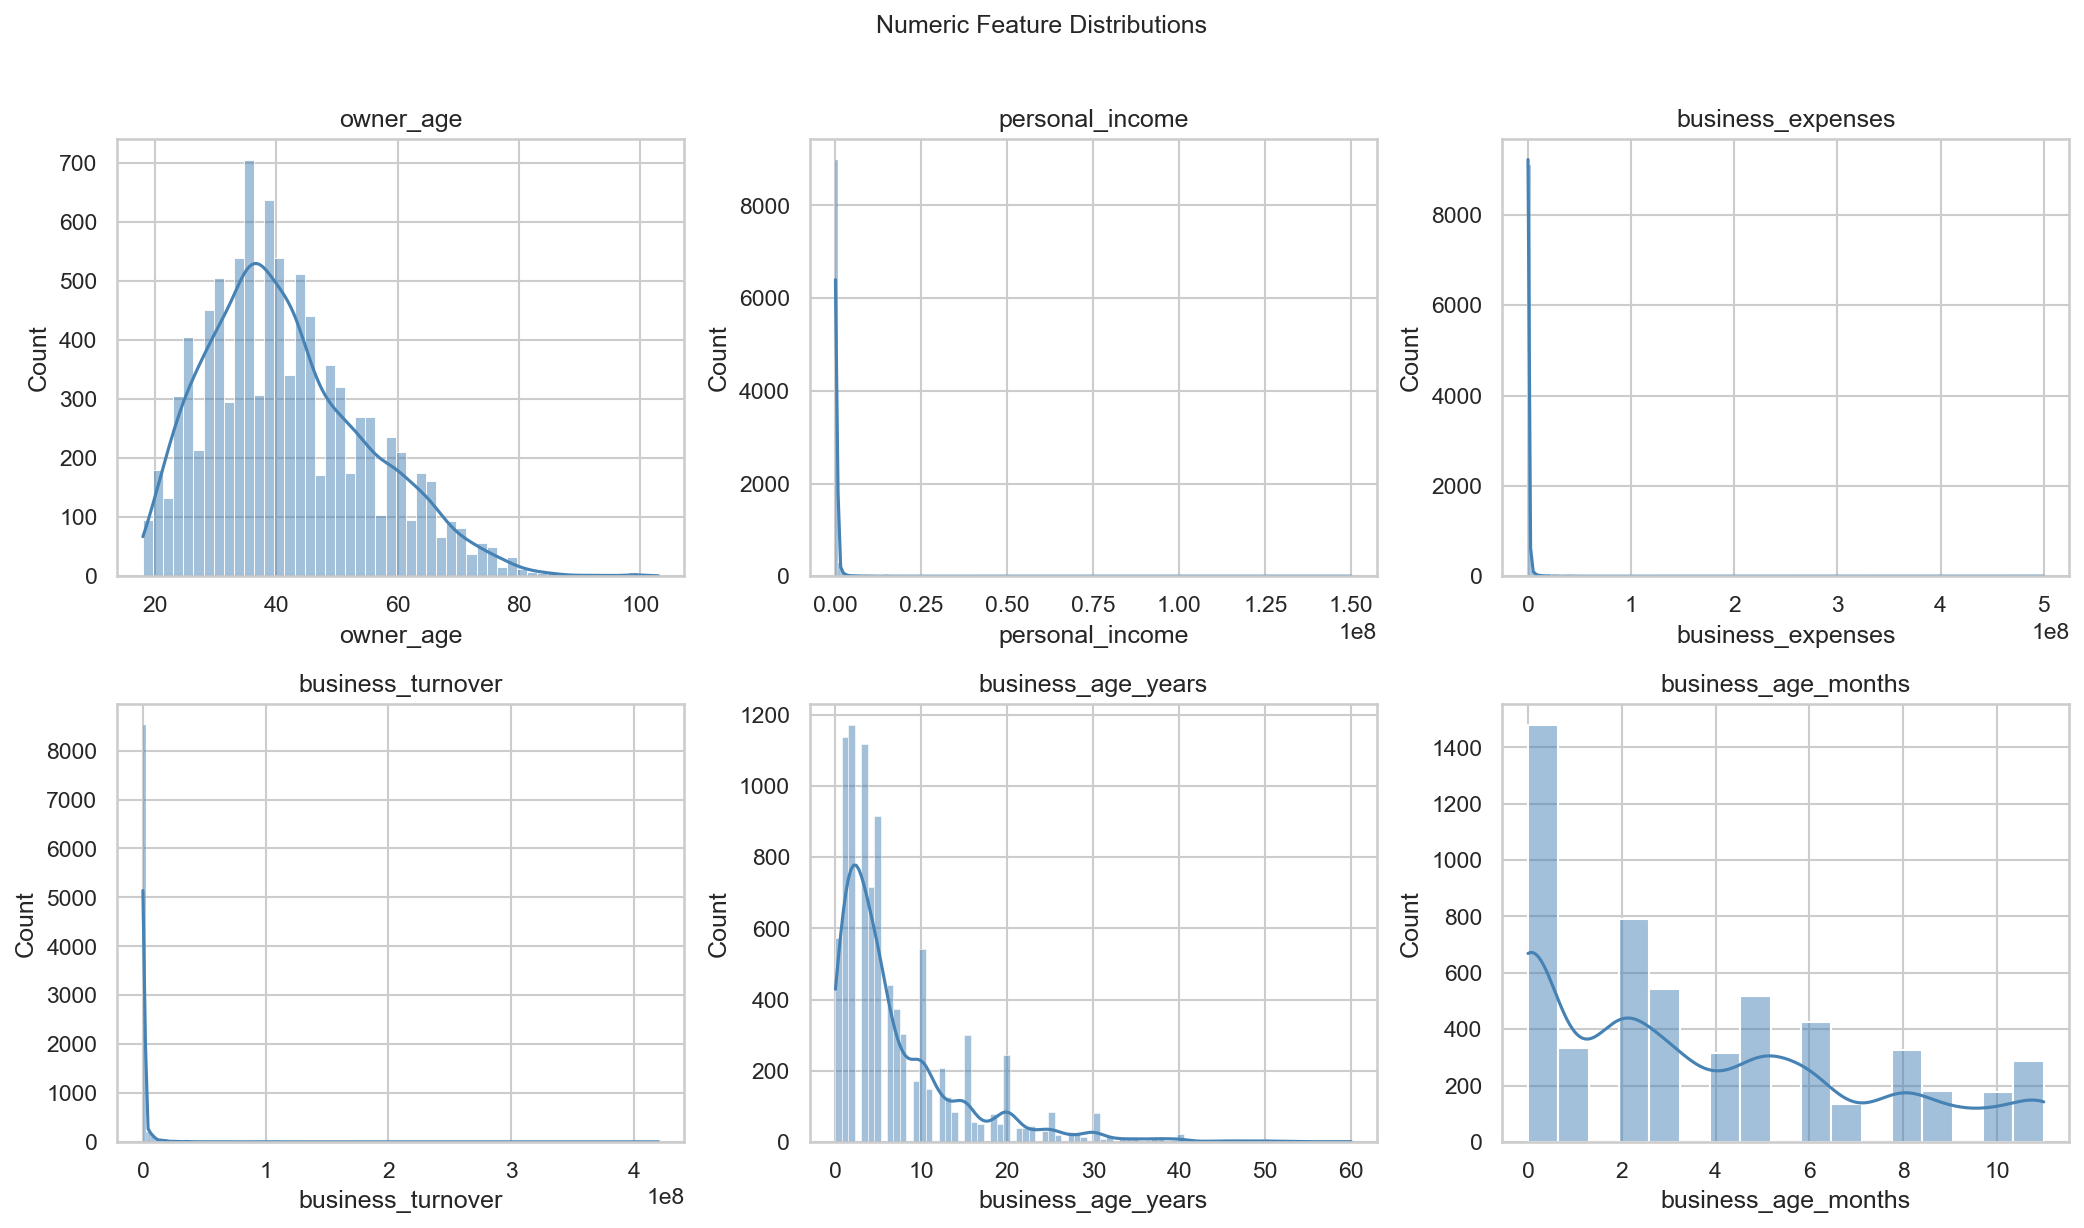

Using cached figure: 05_numeric_boxplots_by_target.png


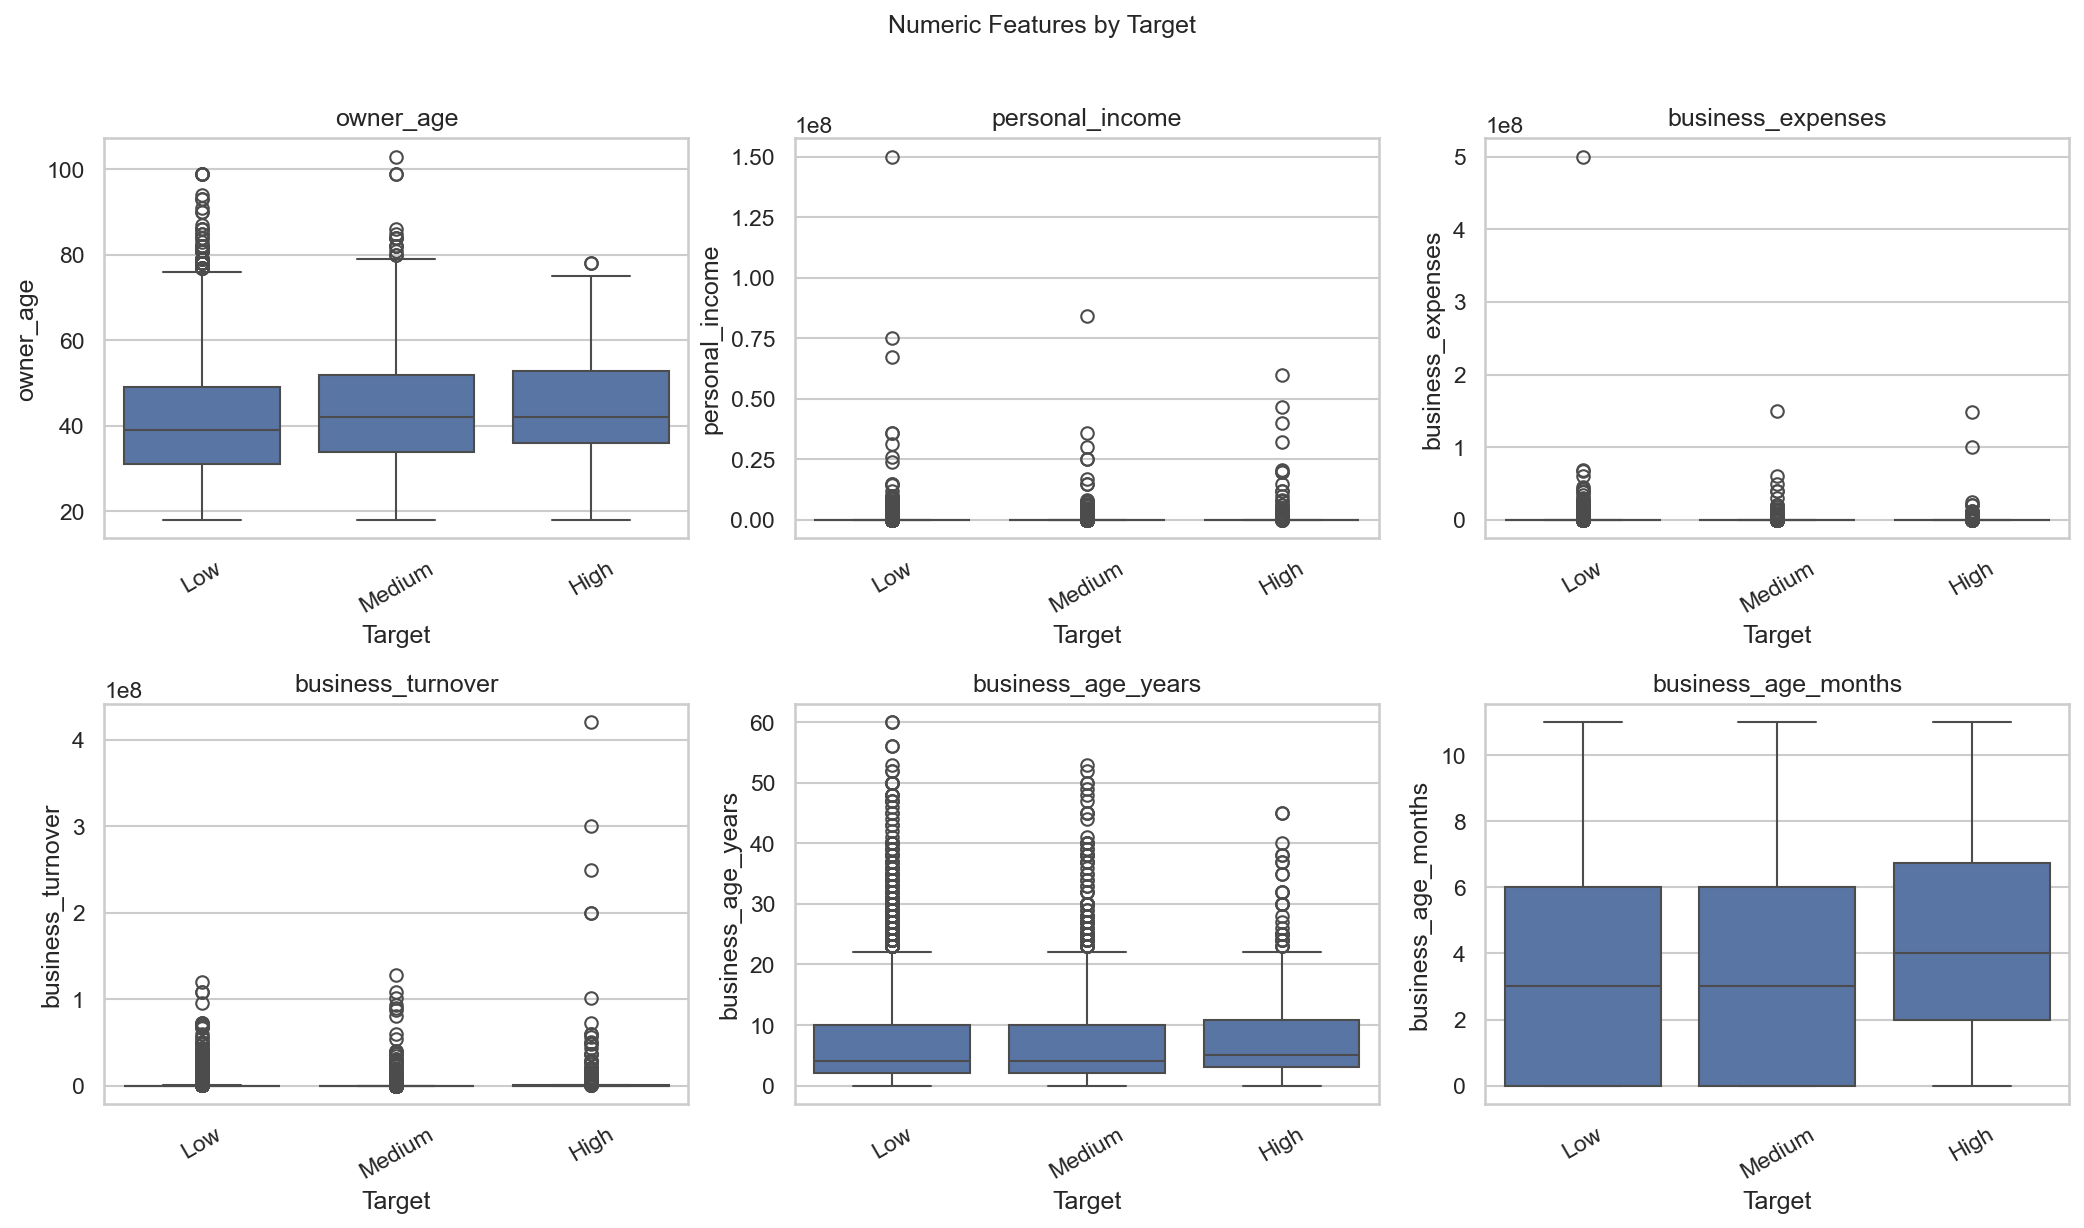

In [6]:
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ["ID"]]
print("Numeric columns:", numeric_cols)

# Distribution grid
n_num = len(numeric_cols)
ncols = 3
nrows = int(np.ceil(n_num / ncols))

if not figure_exists("04_numeric_feature_distributions_histograms.png"):
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = axes.flatten()
    for i, col in enumerate(numeric_cols):
        sns.histplot(train[col].dropna(), kde=True, ax=axes[i], color="steelblue")
        axes[i].set_title(col)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("Numeric Feature Distributions", y=1.02)
save_figure("04_numeric_feature_distributions_histograms.png")

# Boxplots by target
if not figure_exists("05_numeric_boxplots_by_target.png"):
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = axes.flatten()
    for i, col in enumerate(numeric_cols):
        sns.boxplot(data=train, x="Target", y=col, order=CLASS_NAMES, ax=axes[i])
        axes[i].set_title(col)
        axes[i].tick_params(axis="x", rotation=30)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("Numeric Features by Target", y=1.02)
save_figure("05_numeric_boxplots_by_target.png")

## 7. Numeric correlation with target and heatmap

Using cached figure: 06_numeric_correlation_with_target.png


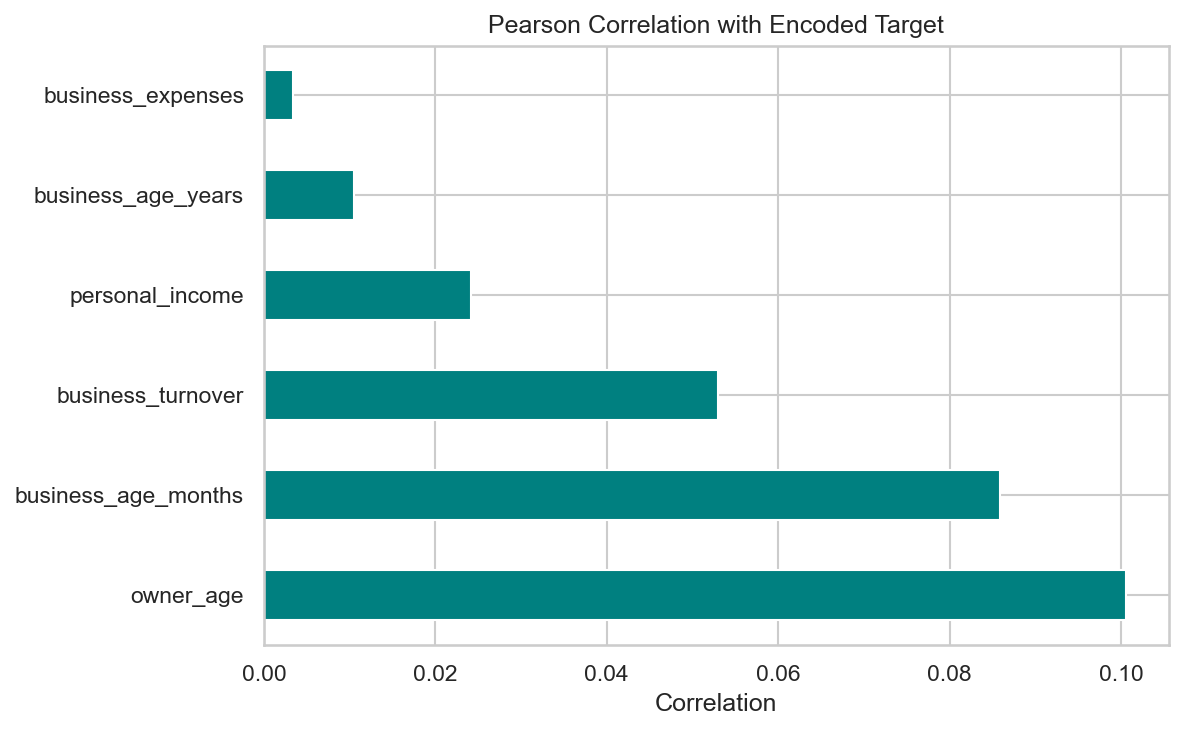

Using cached figure: 07_numeric_correlation_heatmap.png


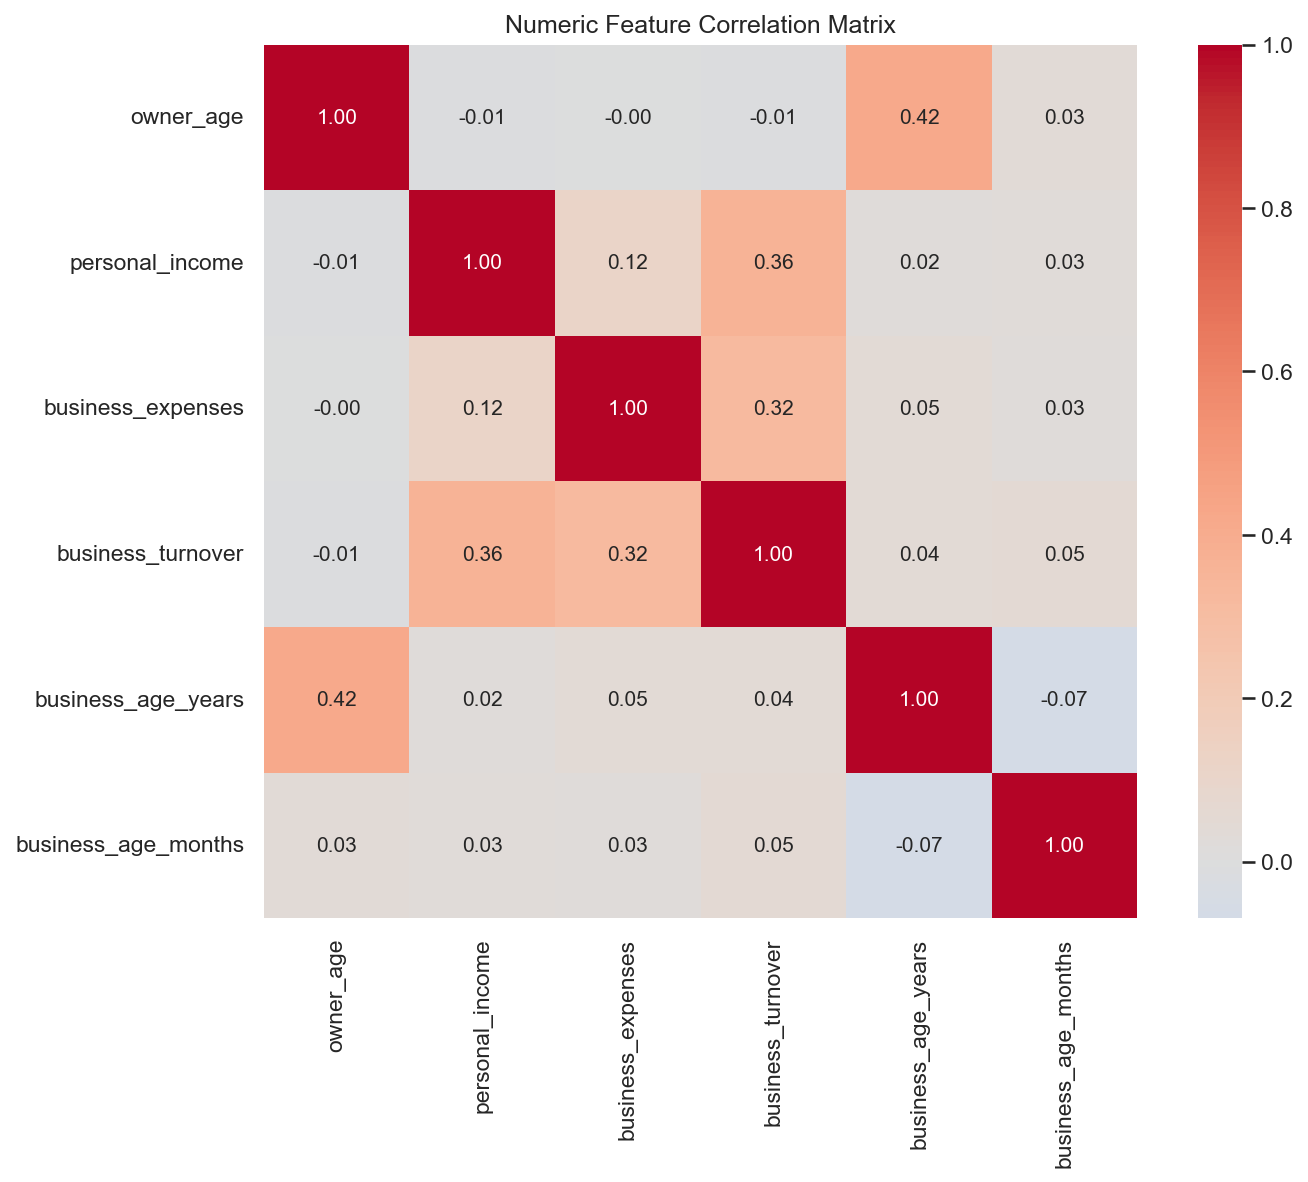

In [7]:
train_num = train.copy()
train_num["target_encoded"] = train_num["Target"].map(TARGET_MAP)

corr_with_target = (
    train_num[numeric_cols + ["target_encoded"]]
    .corr()["target_encoded"]
    .drop("target_encoded")
    .sort_values(key=abs, ascending=False)
)

if not figure_exists("06_numeric_correlation_with_target.png"):
    plt.figure(figsize=(8, 5))
    corr_with_target.plot(kind="barh", color="teal")
    plt.title("Pearson Correlation with Encoded Target")
    plt.xlabel("Correlation")
save_figure("06_numeric_correlation_with_target.png")

if not figure_exists("07_numeric_correlation_heatmap.png"):
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        train_num[numeric_cols].corr(),
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        square=True,
    )
    plt.title("Numeric Feature Correlation Matrix")
save_figure("07_numeric_correlation_heatmap.png")

## 8. Categorical association — Cramér's V and chi-square

,feature,cramers_v,chi2_pvalue,n_categories
27,funeral_insurance,0.546020,0.000000e+00,5
17,has_insurance,0.320221,2.471525e-171,2
13,has_credit_card,0.306203,2.717432e-305,5
22,has_loan_account,0.301170,1.285312e-212,6
21,marketing_word_of_mouth,0.265233,3.312399e-91,2
26,medical_insurance,0.255033,2.716333e-145,6
14,keeps_financial_records,0.220039,3.821191e-157,4
0,country,0.207934,2.180809e-176,4
6,motor_vehicle_insurance,0.203731,5.619841e-129,4
29,uses_friends_family_savings,0.201432,3.188804e-83,6


Using cached figure: 08_top_categorical_cramers_v_with_target.png


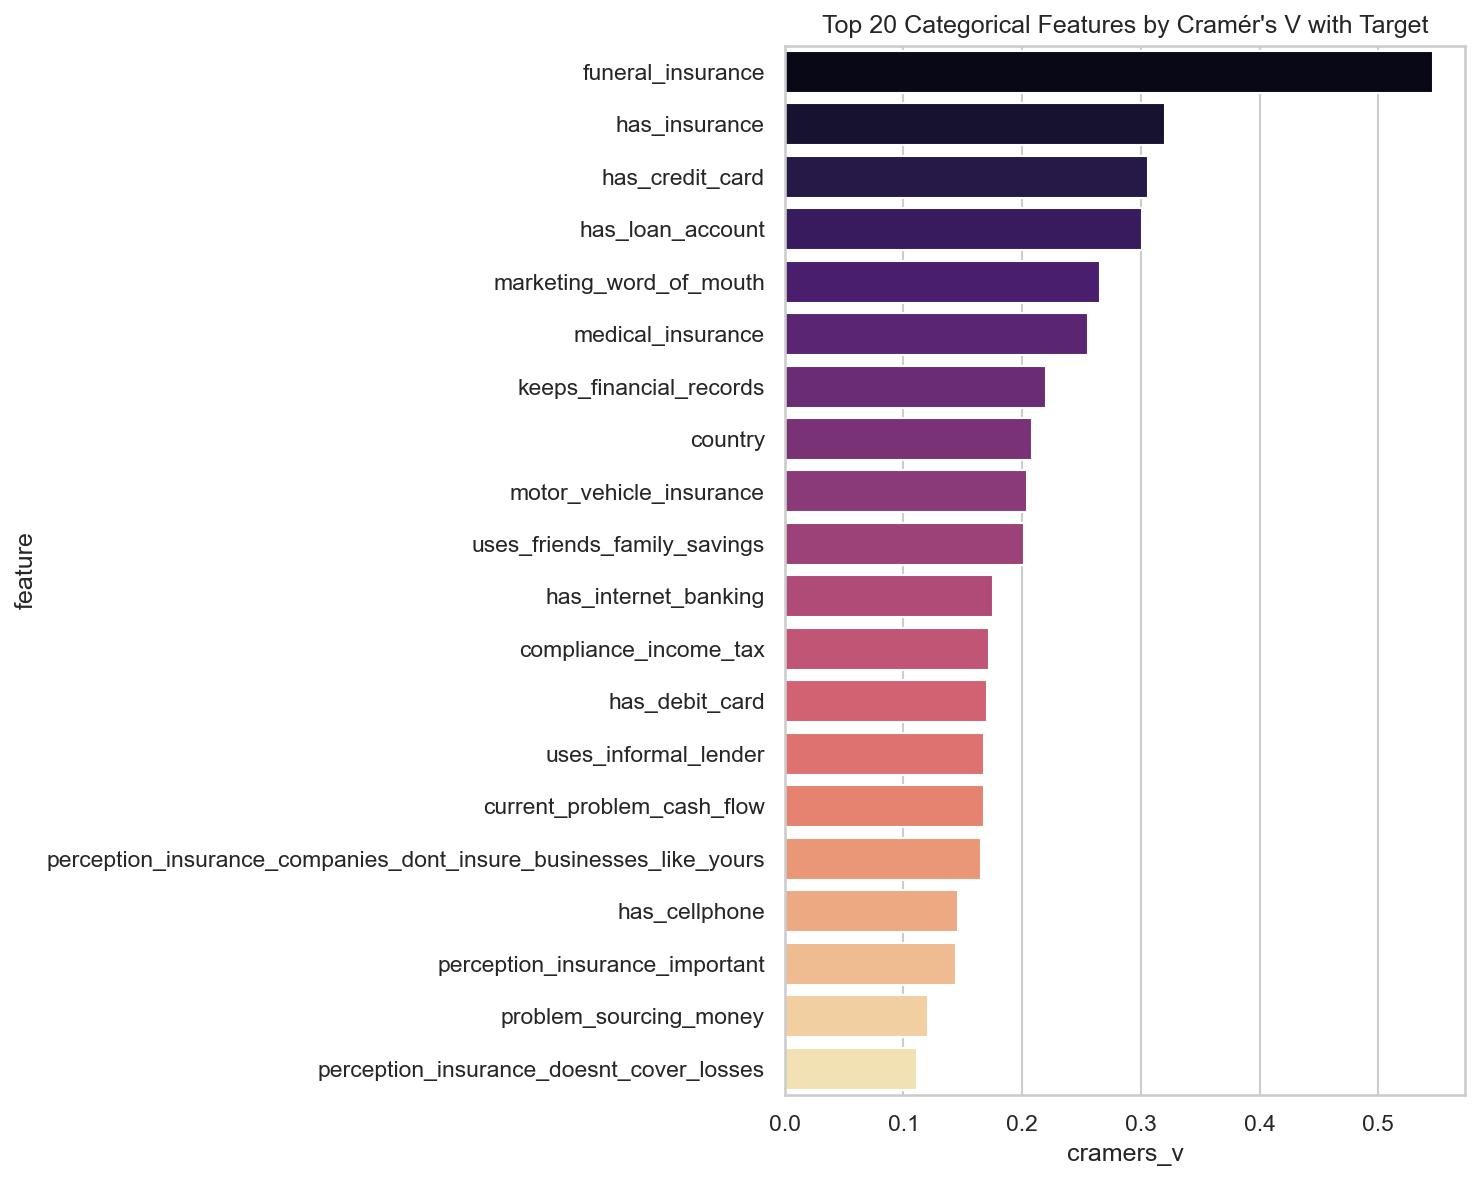

In [8]:
def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    r, k = confusion.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))


cat_cols = [c for c in train.columns if c not in ["ID", "Target"] and train[c].dtype == "object"]

assoc_rows = []
for col in cat_cols:
    sub = train[[col, "Target"]].dropna()
    if sub[col].nunique() < 2:
        continue
    ct = pd.crosstab(sub[col], sub["Target"])
    chi2, p, _, _ = chi2_contingency(ct)
    assoc_rows.append(
        {
            "feature": col,
            "cramers_v": cramers_v(sub[col], sub["Target"]),
            "chi2_pvalue": p,
            "n_categories": sub[col].nunique(),
        }
    )

assoc_df = pd.DataFrame(assoc_rows).sort_values("cramers_v", ascending=False)
display(assoc_df.head(15))

if not figure_exists("08_top_categorical_cramers_v_with_target.png"):
    plt.figure(figsize=(10, 8))
    top_assoc = assoc_df.head(20)
    sns.barplot(data=top_assoc, y="feature", x="cramers_v", palette="magma")
    plt.title("Top 20 Categorical Features by Cramér's V with Target")
save_figure("08_top_categorical_cramers_v_with_target.png")

## 9. Mutual information scores

,feature,mutual_information
33,funeral_insurance,0.223221
32,medical_insurance,0.066841
11,motor_vehicle_insurance,0.057563
18,has_credit_card,0.051364
22,has_insurance,0.050536
27,has_loan_account,0.048544
0,country,0.044940
19,keeps_financial_records,0.044800
35,uses_friends_family_savings,0.044158
7,personal_income,0.037403


Using cached figure: 09_mutual_information_top25.png


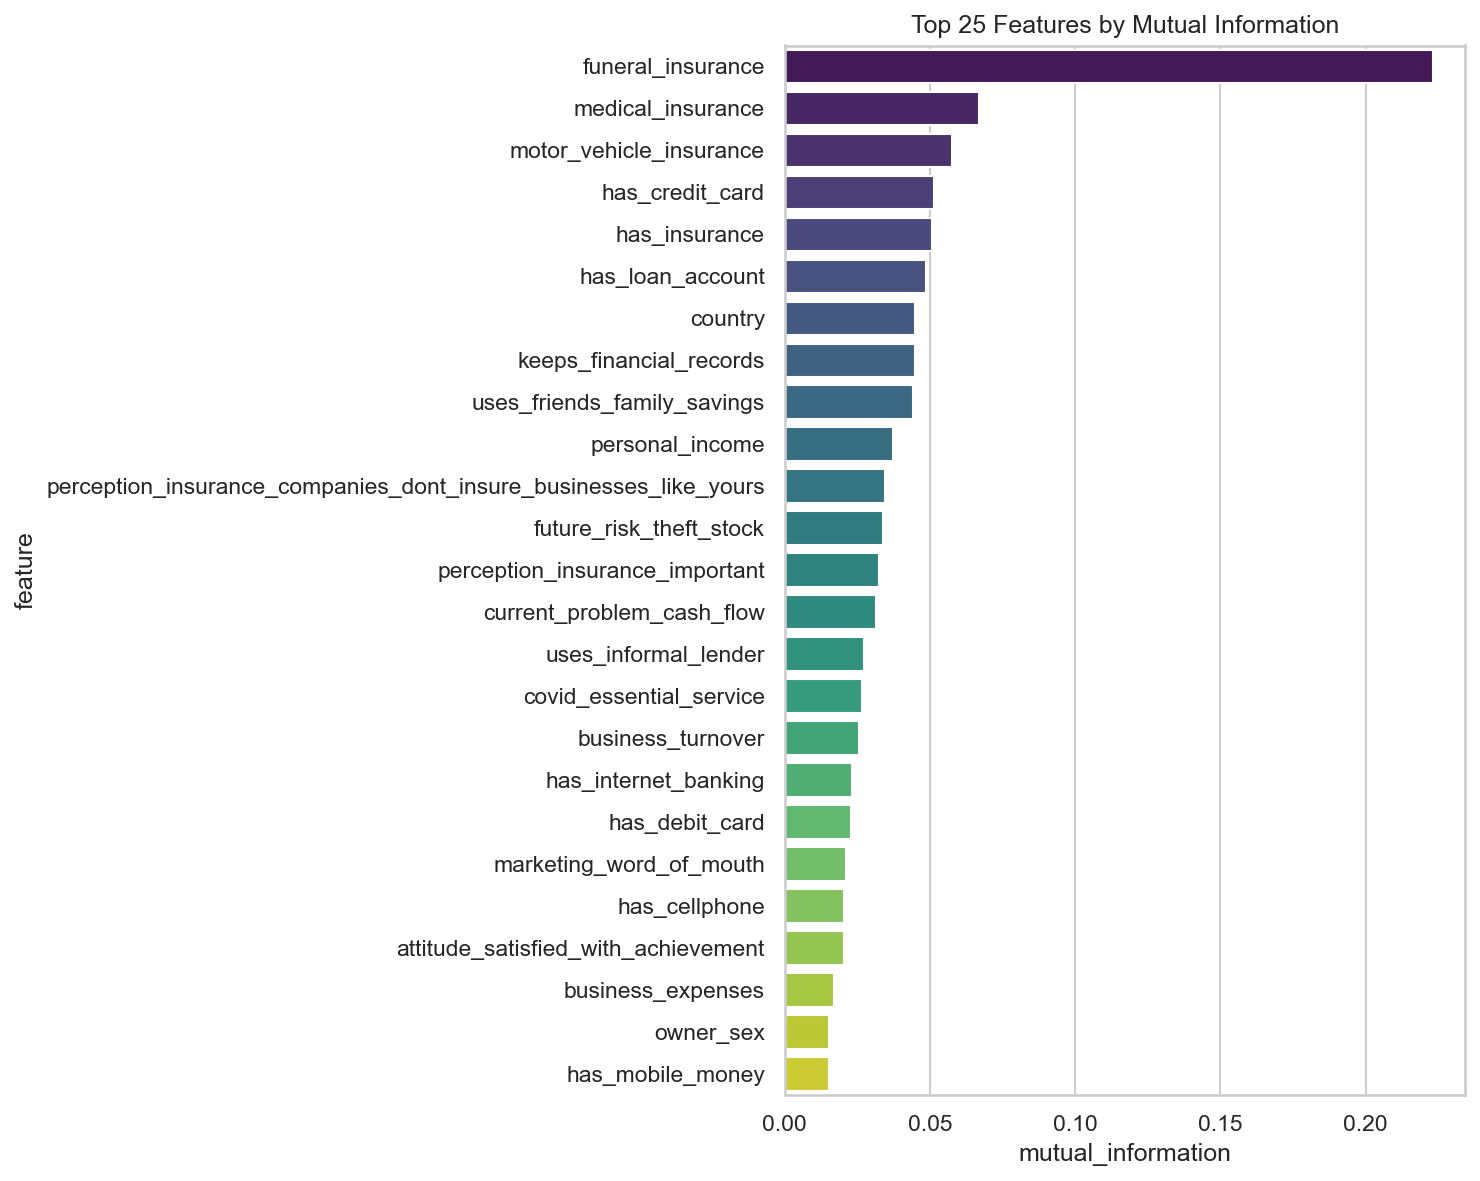

In [9]:
# Encode categoricals for MI
mi_df = train.drop(columns=["ID"]).copy()
mi_df["target_encoded"] = mi_df["Target"].map(TARGET_MAP)
for col in mi_df.select_dtypes(include="object").columns:
    if col != "Target":
        mi_df[col] = LabelEncoder().fit_transform(mi_df[col].astype(str))

mi_df = mi_df.fillna(-1)
X_mi = mi_df.drop(columns=["Target", "target_encoded"])
y_mi = mi_df["target_encoded"]

mi_scores = mutual_info_classif(X_mi, y_mi, random_state=RANDOM_STATE, discrete_features="auto")
mi_result = (
    pd.DataFrame({"feature": X_mi.columns, "mutual_information": mi_scores})
    .sort_values("mutual_information", ascending=False)
)
display(mi_result.head(20))

if not figure_exists("09_mutual_information_top25.png"):
    plt.figure(figsize=(10, 8))
    sns.barplot(
        data=mi_result.head(25),
        y="feature",
        x="mutual_information",
        palette="viridis",
    )
    plt.title("Top 25 Features by Mutual Information")
save_figure("09_mutual_information_top25.png")

## 10. Top categorical features vs target

Using cached figure: 10_top_categorical_target_composition_stacked.png


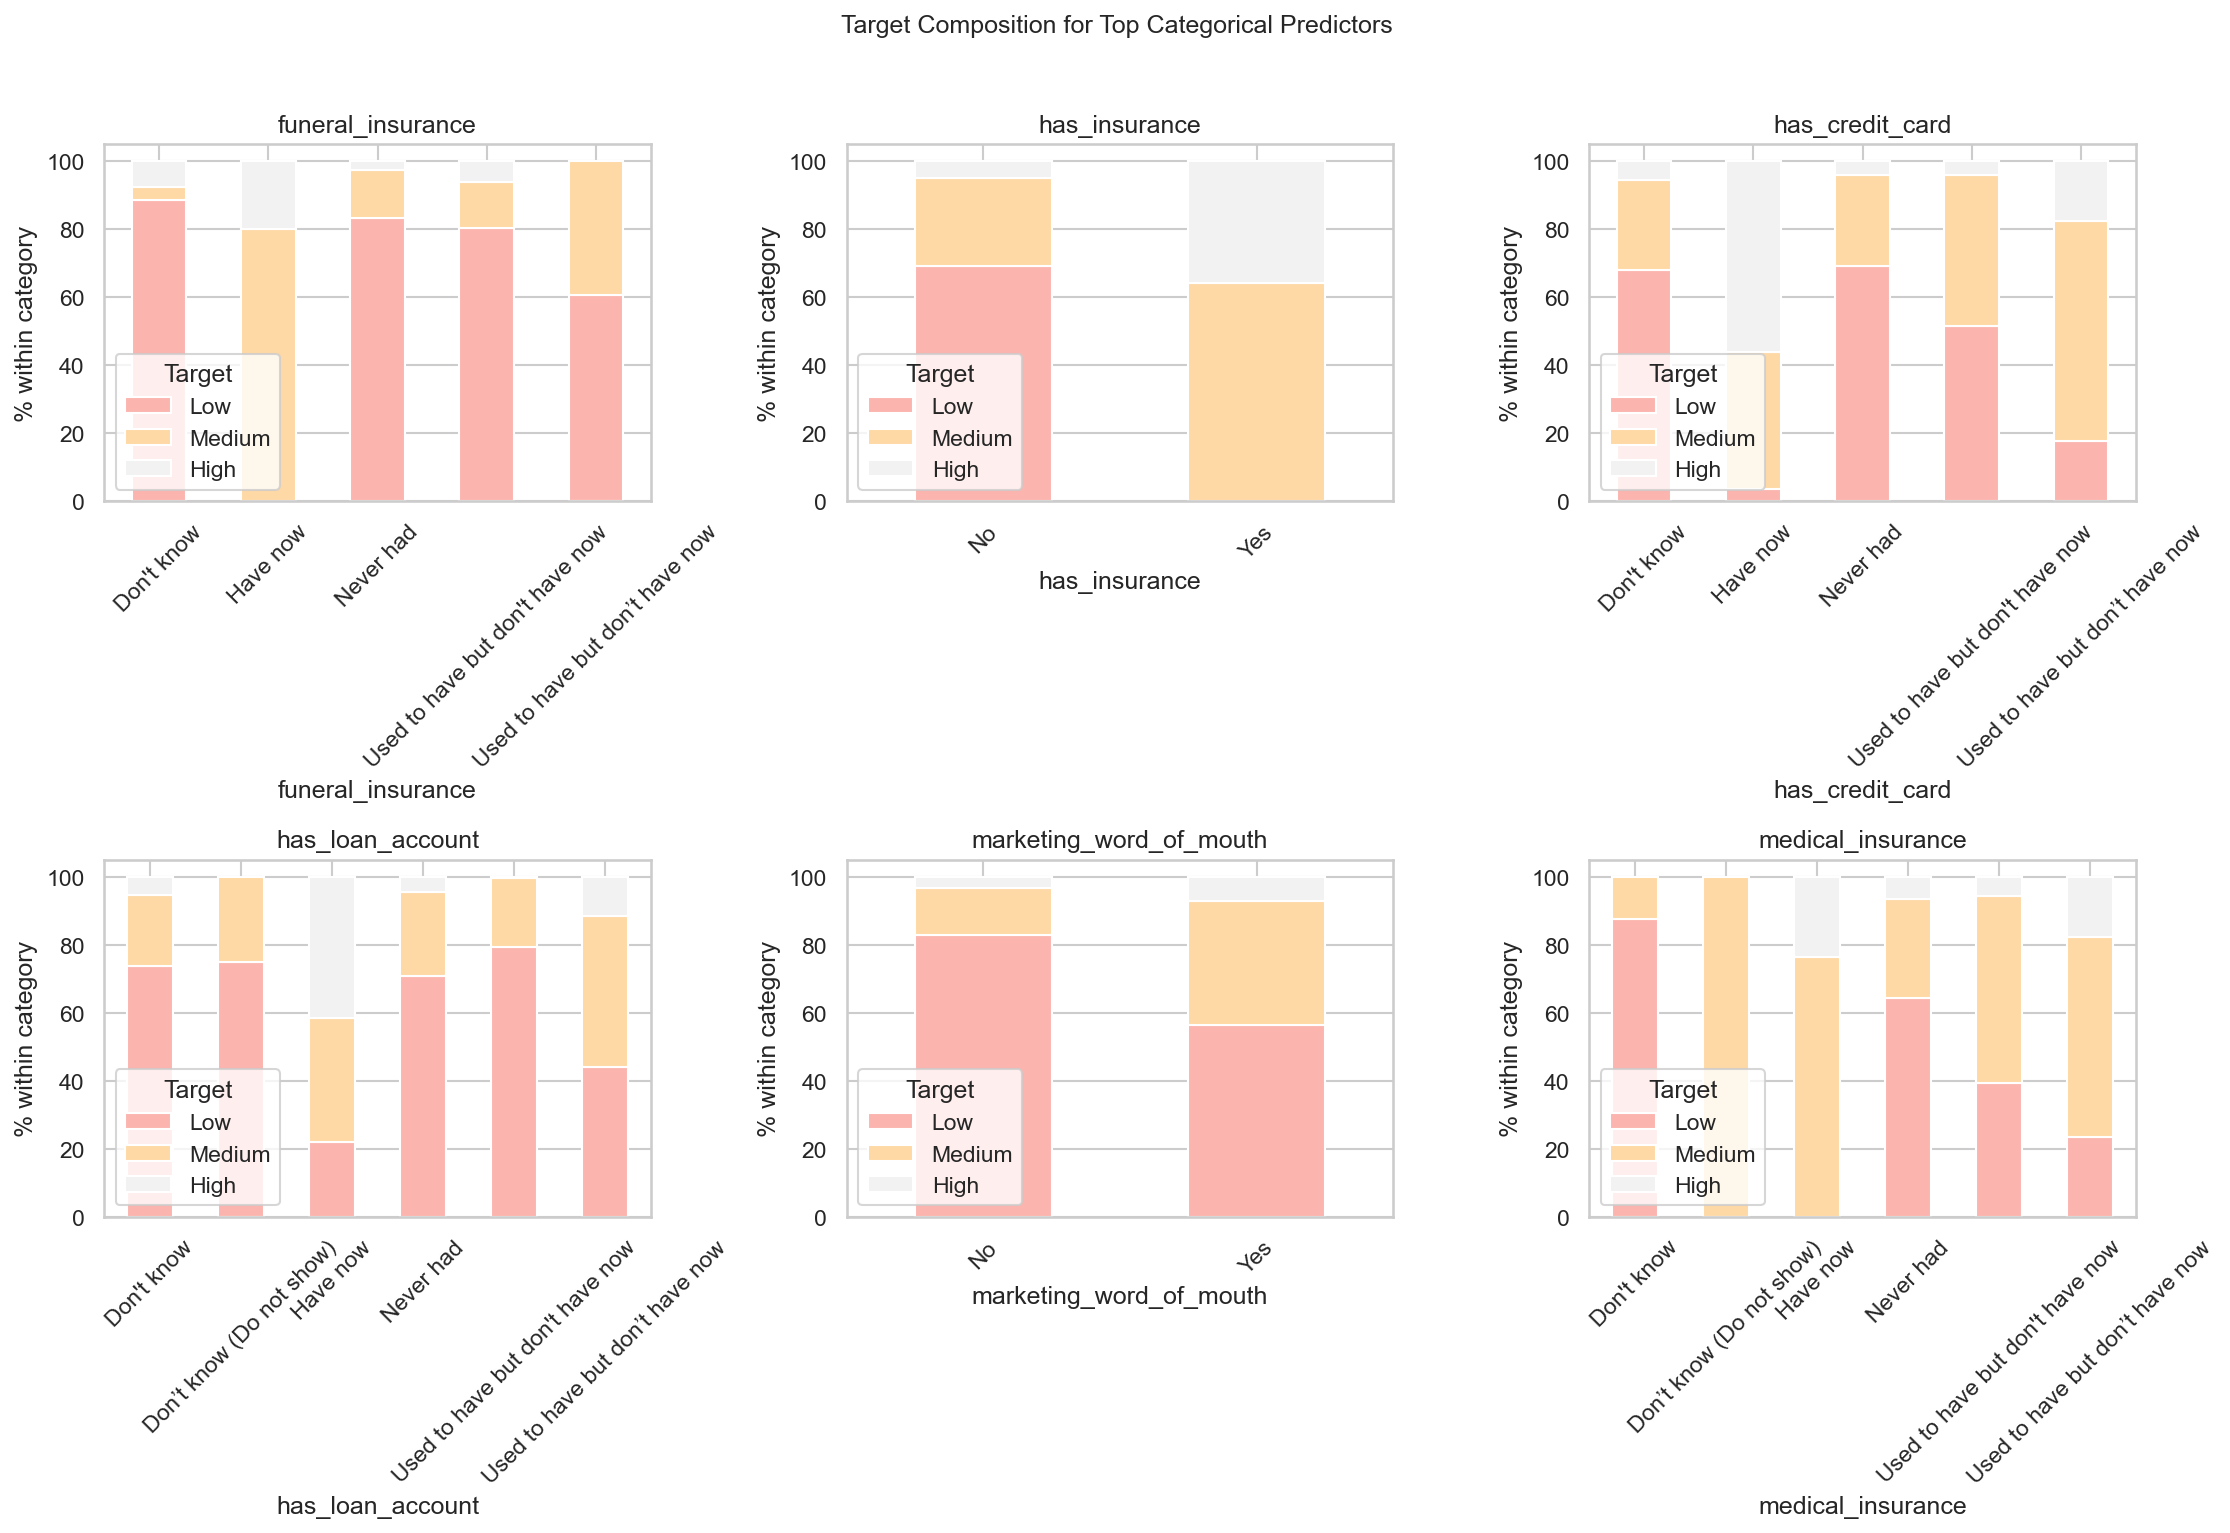

In [10]:
top_cat = assoc_df.head(6)["feature"].tolist()

if not figure_exists("10_top_categorical_target_composition_stacked.png"):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    for ax, col in zip(axes, top_cat):
        ct_pct = pd.crosstab(train[col], train["Target"], normalize="index")[CLASS_NAMES] * 100
        ct_pct.plot(kind="bar", stacked=True, ax=ax, colormap="Pastel1")
        ax.set_title(col)
        ax.set_ylabel("% within category")
        ax.tick_params(axis="x", rotation=45)
    plt.suptitle("Target Composition for Top Categorical Predictors", y=1.02)
save_figure("10_top_categorical_target_composition_stacked.png")

## 11. Insurance and financial services — decision tiers

Using cached figure: 11_insurance_adoption_tier_vs_target.png


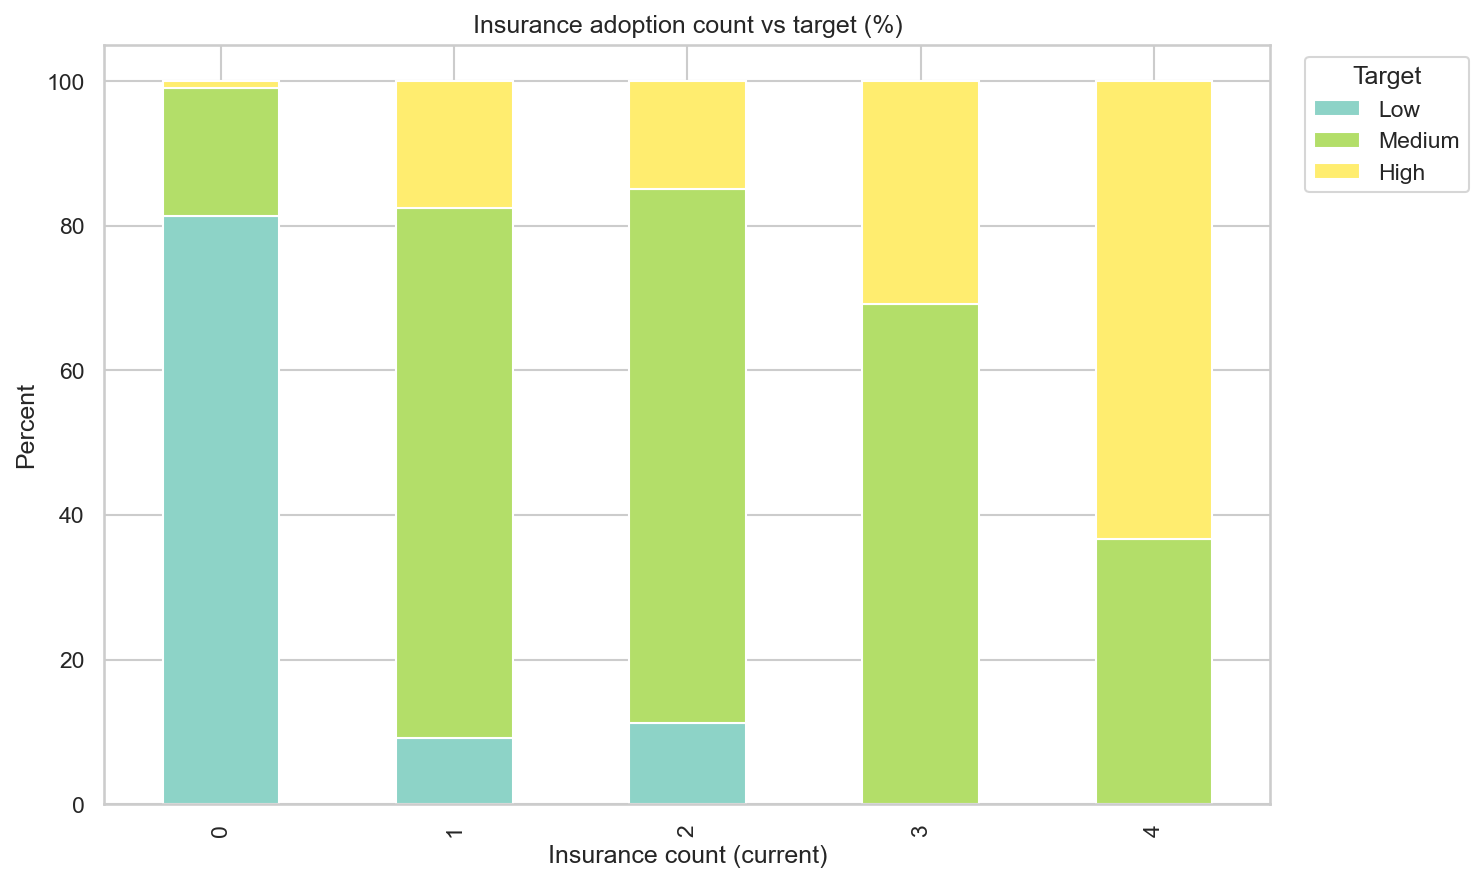

Using cached figure: 12_financial_services_adoption_tier_vs_target.png


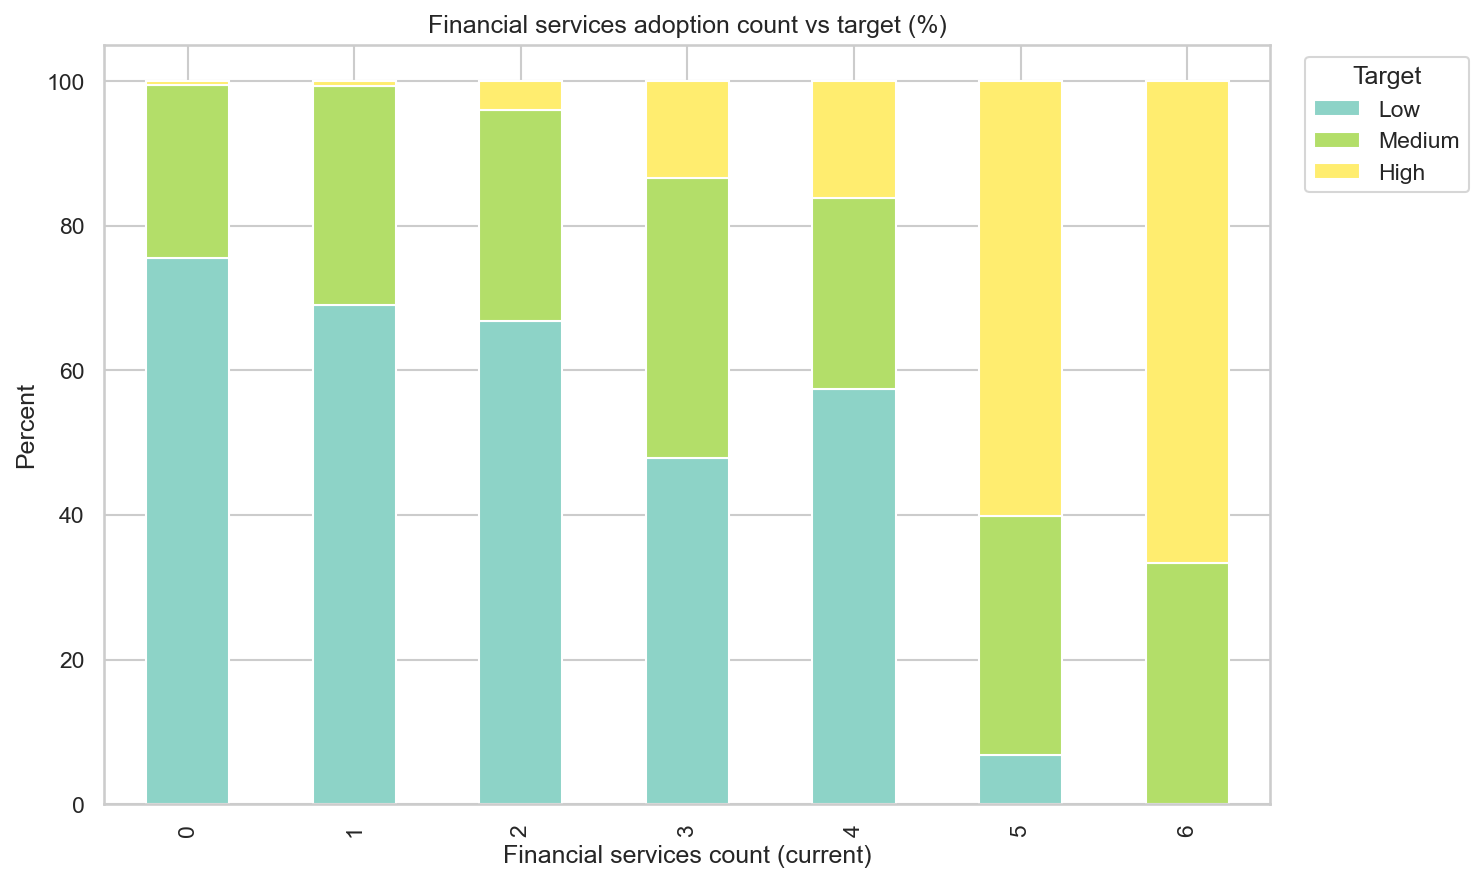

In [11]:
def is_current_holder(val):
    if pd.isna(val):
        return 0
    s = str(val).lower()
    return int("have now" in s or s == "yes")


insurance_cols = [
    "has_insurance",
    "motor_vehicle_insurance",
    "medical_insurance",
    "funeral_insurance",
]
fin_cols = [
    "has_mobile_money",
    "has_credit_card",
    "has_loan_account",
    "has_internet_banking",
    "has_debit_card",
    "has_cellphone",
]

eda = train.copy()
eda["insurance_count"] = sum(eda[c].apply(is_current_holder) for c in insurance_cols)
eda["financial_service_count"] = sum(eda[c].apply(is_current_holder) for c in fin_cols)

for count_col, title_prefix in [
    ("insurance_count", "Insurance"),
    ("financial_service_count", "Financial services"),
]:
    fname = (
        "11_insurance_adoption_tier_vs_target.png"
        if "insurance" in count_col
        else "12_financial_services_adoption_tier_vs_target.png"
    )
    if not figure_exists(fname):
        tier_target = pd.crosstab(eda[count_col], eda["Target"], normalize="index")[CLASS_NAMES] * 100
        plt.figure(figsize=(9, 5))
        tier_target.plot(kind="bar", stacked=True, colormap="Set3")
        plt.title(f"{title_prefix} adoption count vs target (%)")
        plt.xlabel(f"{title_prefix} count (current)")
        plt.ylabel("Percent")
        plt.legend(title="Target", bbox_to_anchor=(1.02, 1))
    save_figure(fname)

## 12. Feature engineering (v3) — preview and engineered-target analysis

Engineered feature count: 21


,count,mean,std,min,25%,50%,75%,max
funeral_insurance_detailed,9618.0,0.518299,1.119035,0.0,0.0,0.0,0.0,3.0
has_funeral_insurance_now,9618.0,0.186005,0.389131,0.0,0.0,0.0,0.0,1.0
has_insurance_current,9618.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
motor_vehicle_insurance_current,9618.0,0.035766,0.185717,0.0,0.0,0.0,0.0,1.0
medical_insurance_current,9618.0,0.064358,0.245403,0.0,0.0,0.0,0.0,1.0
funeral_insurance_current,9618.0,0.186005,0.389131,0.0,0.0,0.0,0.0,1.0
insurance_current_count,9618.0,0.286130,0.615944,0.0,0.0,0.0,0.0,3.0
has_mobile_money_current,9618.0,0.521834,0.499549,0.0,0.0,1.0,1.0,1.0
has_credit_card_current,9618.0,0.038677,0.192835,0.0,0.0,0.0,0.0,1.0
has_loan_account_current,9618.0,0.113849,0.317644,0.0,0.0,0.0,0.0,1.0


Using cached figure: 13_engineered_features_correlation_heatmap.png


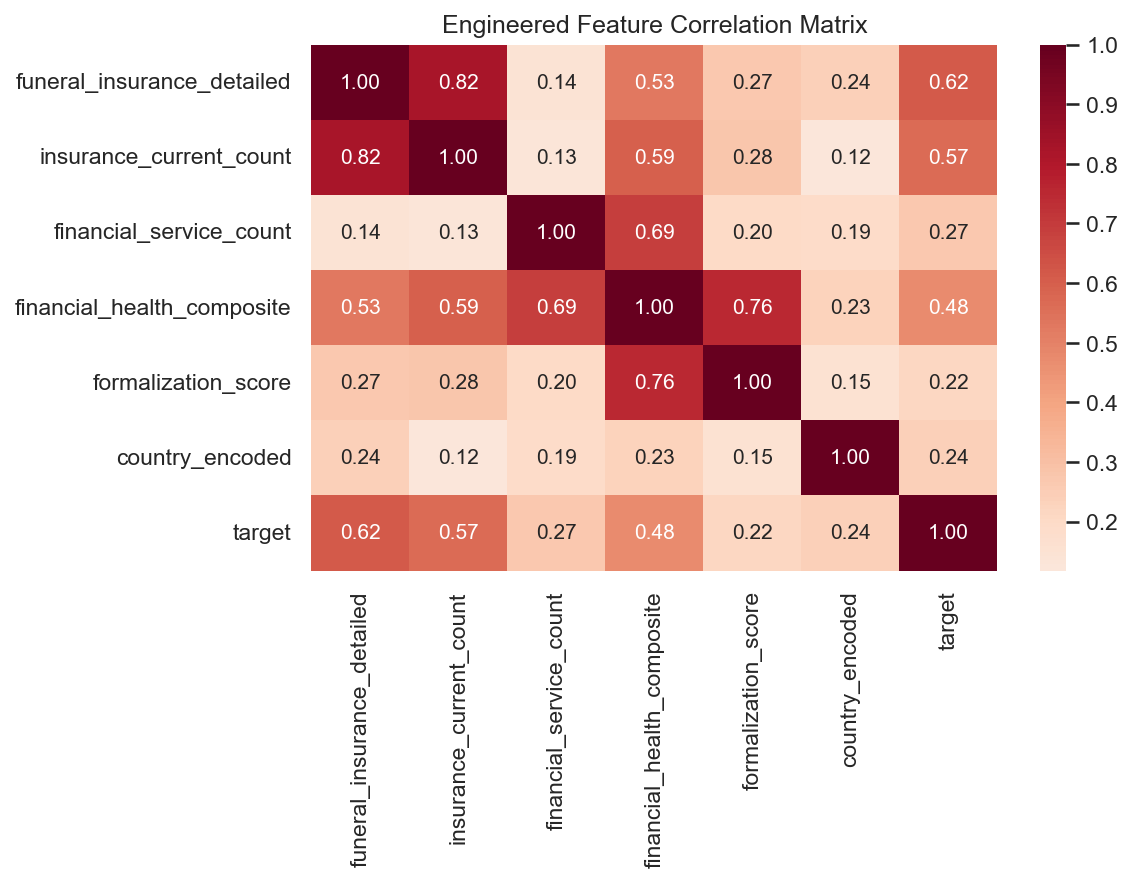

In [12]:
# Reuse same engineering logic as production model (abbreviated for EDA)
raw_cols = [c for c in train.columns if c not in ["ID", "Target"]]


def create_v3_features_eda(df):
    f = pd.DataFrame(index=df.index)
    if "funeral_insurance" in df.columns:
        funeral_map = {"Have now": 3, "Used to have but don't have now": 1, "Never had": 0, "Don't know": 0.5}
        f["funeral_insurance_detailed"] = df["funeral_insurance"].apply(
            lambda x: funeral_map.get(str(x).strip() if pd.notna(x) else "Never had", 0)
        )
        f["has_funeral_insurance_now"] = df["funeral_insurance"].apply(
            lambda x: 1 if pd.notna(x) and "have now" in str(x).lower() else 0
        )
    ins_cols = ["has_insurance", "motor_vehicle_insurance", "medical_insurance", "funeral_insurance"]
    scores = []
    for col in ins_cols:
        if col in df.columns:
            cur = df[col].apply(lambda x: 1 if pd.notna(x) and "have now" in str(x).lower() else 0)
            f[f"{col}_current"] = cur
            scores.append(cur)
    if scores:
        f["insurance_current_count"] = pd.concat(scores, axis=1).sum(axis=1)
    fin_cols = [
        "has_mobile_money",
        "has_credit_card",
        "has_loan_account",
        "has_internet_banking",
        "has_debit_card",
        "has_cellphone",
    ]
    fscores = []
    for col in fin_cols:
        if col in df.columns:
            cur = df[col].apply(
                lambda x: 1 if pd.notna(x) and ("have now" in str(x).lower() or str(x).lower() == "yes") else 0
            )
            f[f"{col}_current"] = cur
            fscores.append(cur)
    if fscores:
        f["financial_service_count"] = pd.concat(fscores, axis=1).sum(axis=1)
    if "country" in df.columns:
        f["country_encoded"] = df["country"].map({"eswatini": 3, "malawi": 0, "zimbabwe": 1, "lesotho": 2}).fillna(1)
    if "keeps_financial_records" in df.columns:
        rm = {"Yes, always": 3, "Yes, sometimes": 2, "Yes": 2, "No": 0}
        f["keeps_records_score"] = df["keeps_financial_records"].apply(
            lambda x: rm.get(str(x).strip() if pd.notna(x) else "No", 0)
        )
        f["formalization_score"] = f["keeps_records_score"] / 3
    for col in ["personal_income", "business_expenses", "business_turnover"]:
        if col in df.columns:
            f[f"log_{col}"] = np.log1p(df[col].fillna(0).clip(lower=0))
    parts = []
    if "insurance_current_count" in f.columns:
        parts.append(f["insurance_current_count"] * 0.4)
    if "financial_service_count" in f.columns:
        parts.append(f["financial_service_count"] * 0.3)
    if "formalization_score" in f.columns:
        parts.append(f["formalization_score"] * 3 * 0.3)
    if parts:
        f["financial_health_composite"] = pd.concat(parts, axis=1).sum(axis=1)
    return f


eng = create_v3_features_eda(train[raw_cols])
print("Engineered feature count:", eng.shape[1])
display(eng.describe().T.head(15))

# Correlation among key engineered features
key_eng = [
    c
    for c in [
        "funeral_insurance_detailed",
        "insurance_current_count",
        "financial_service_count",
        "financial_health_composite",
        "formalization_score",
        "country_encoded",
    ]
    if c in eng.columns
]
if key_eng and not figure_exists("13_engineered_features_correlation_heatmap.png"):
    eng_plot = eng[key_eng].copy()
    eng_plot["target"] = train["Target"].map(TARGET_MAP)
    plt.figure(figsize=(8, 6))
    sns.heatmap(eng_plot.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0)
    plt.title("Engineered Feature Correlation Matrix")
if key_eng:
    save_figure("13_engineered_features_correlation_heatmap.png")

## 13. Engineered features vs target

Using cached figure: 14_engineered_features_boxplots_by_target.png


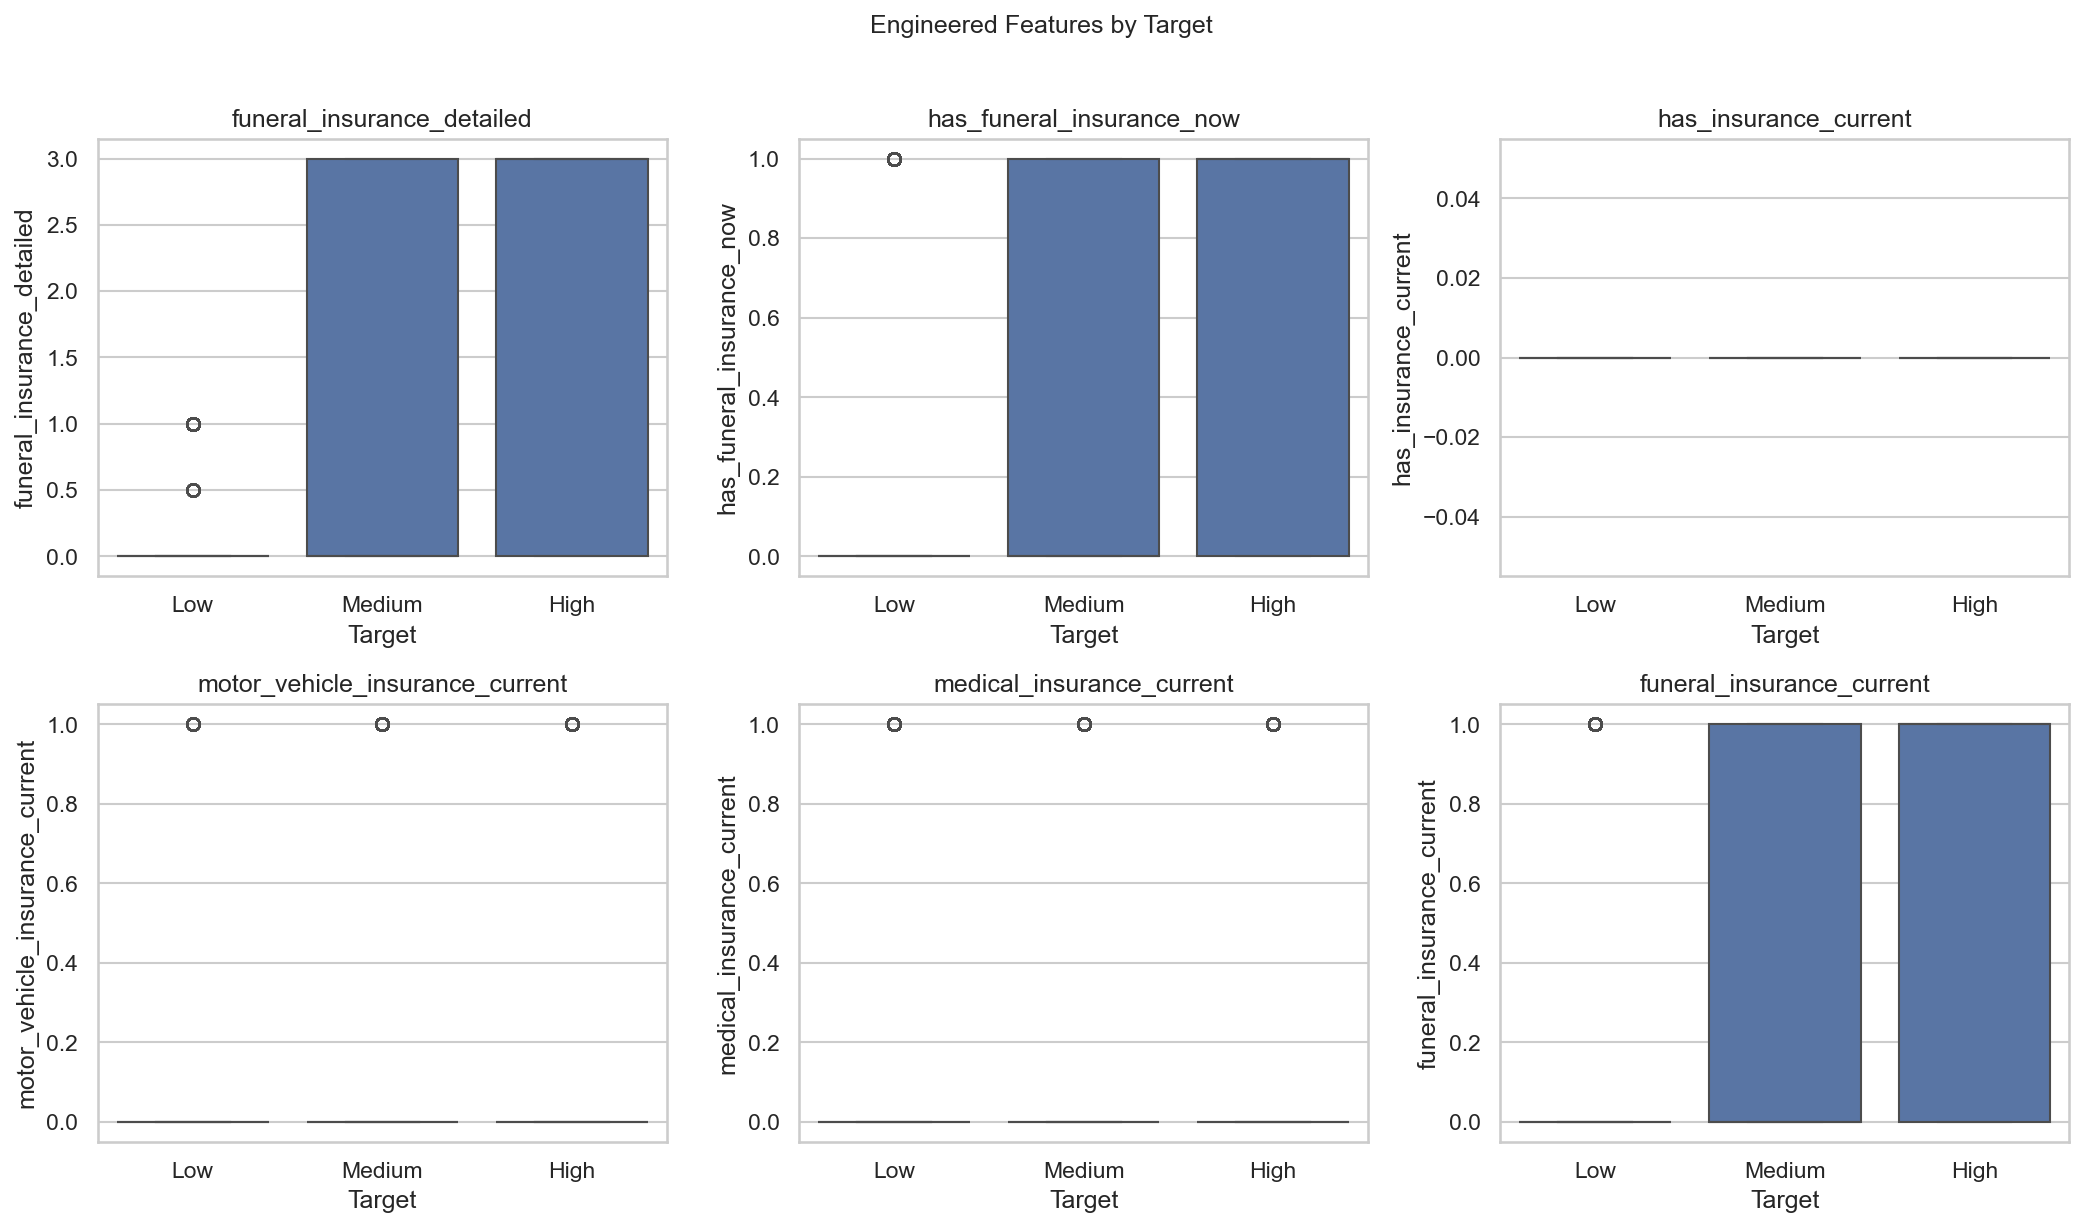

In [13]:
plot_eng = [c for c in eng.columns if eng[c].nunique() <= 20][:6]

if not figure_exists("14_engineered_features_boxplots_by_target.png"):
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()
    for ax, col in zip(axes, plot_eng):
        sns.boxplot(
            data=pd.concat([eng[[col]], train["Target"]], axis=1),
            x="Target",
            y=col,
            order=CLASS_NAMES,
            ax=ax,
        )
        ax.set_title(col)
    plt.suptitle("Engineered Features by Target", y=1.02)
save_figure("14_engineered_features_boxplots_by_target.png")

## 14. Preprocessing matrix for modeling benchmarks

In [14]:
X_raw = train[raw_cols].copy()
X_eng = pd.concat([X_raw, eng], axis=1)

# Simple encoding for tree models
X_model = X_eng.copy()
for col in X_model.select_dtypes(include="object").columns:
    X_model[col] = LabelEncoder().fit_transform(X_model[col].astype(str))
X_model = X_model.fillna(-1)

y = train["Target"].map(TARGET_MAP)
print("Modeling matrix shape:", X_model.shape)

Modeling matrix shape: (9618, 58)


## 15. Random Forest — baseline feature importance

,feature,importance
57,financial_health_composite,0.092541
43,insurance_current_count,0.075355
50,financial_service_count,0.057909
27,has_loan_account,0.045755
33,funeral_insurance,0.042279
18,has_credit_card,0.042262
37,funeral_insurance_detailed,0.035878
45,has_credit_card_current,0.031266
42,funeral_insurance_current,0.030287
22,has_insurance,0.030238


Using cached figure: 15_random_forest_feature_importance_top30.png


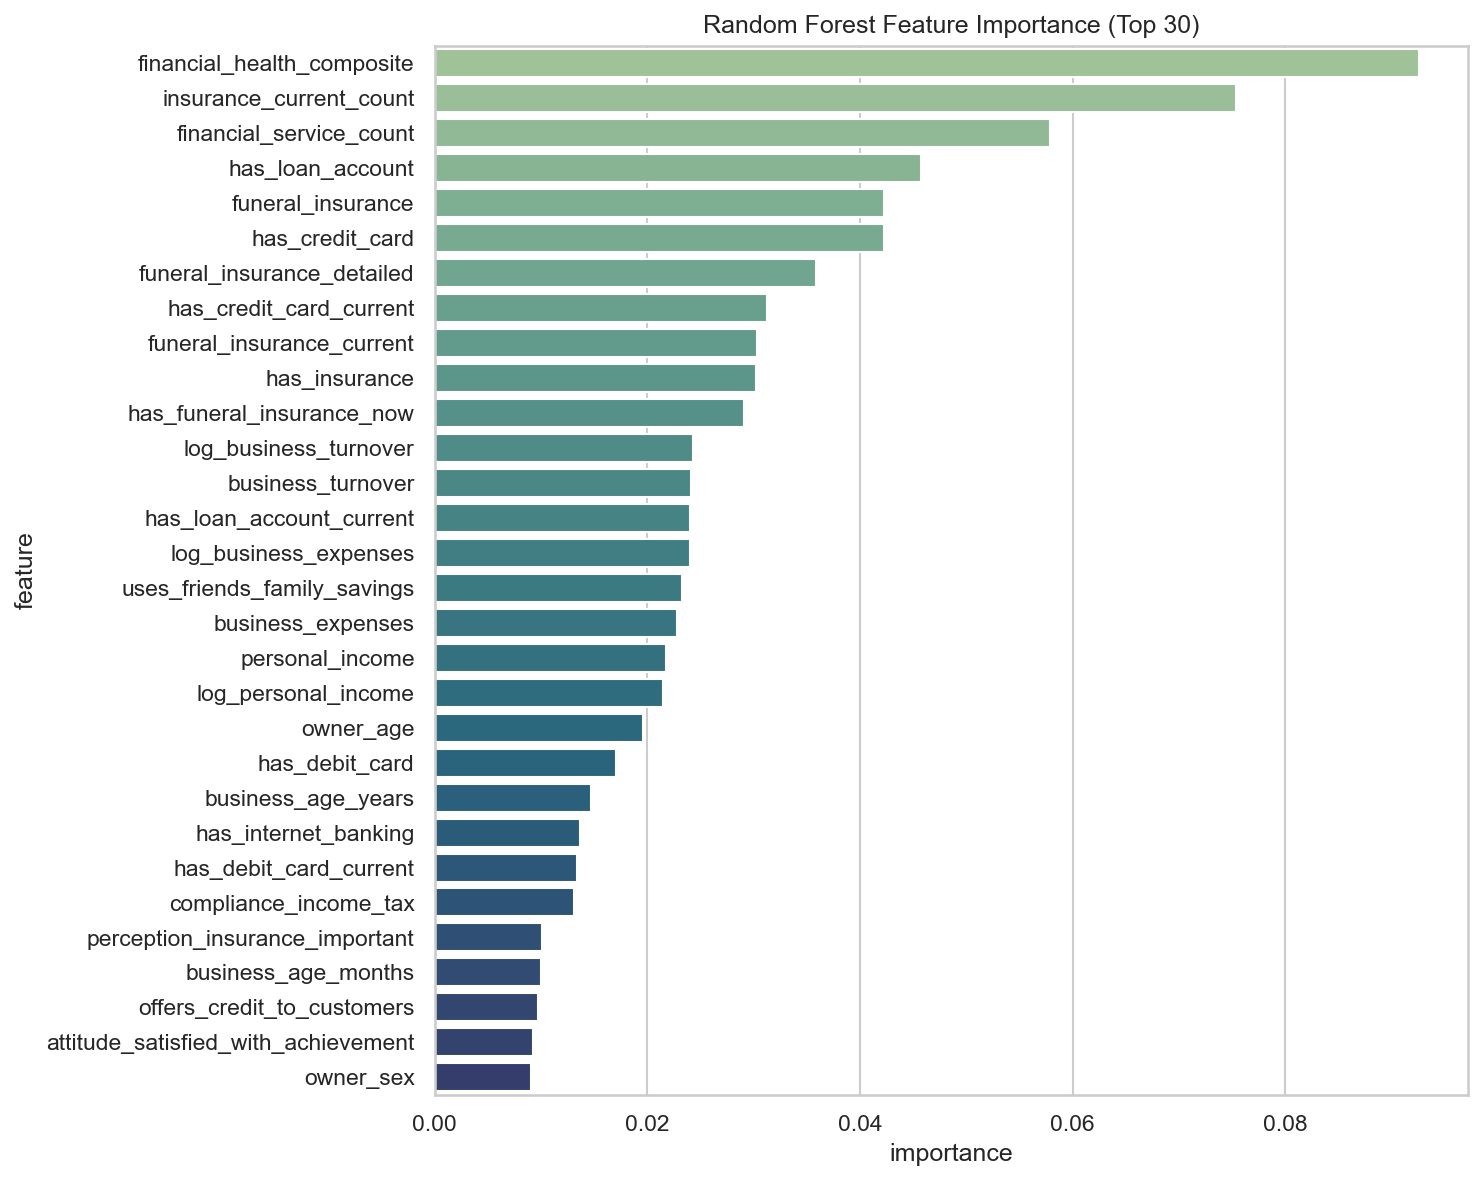

Using cached figure: 16_engineered_features_rf_importance_top15.png


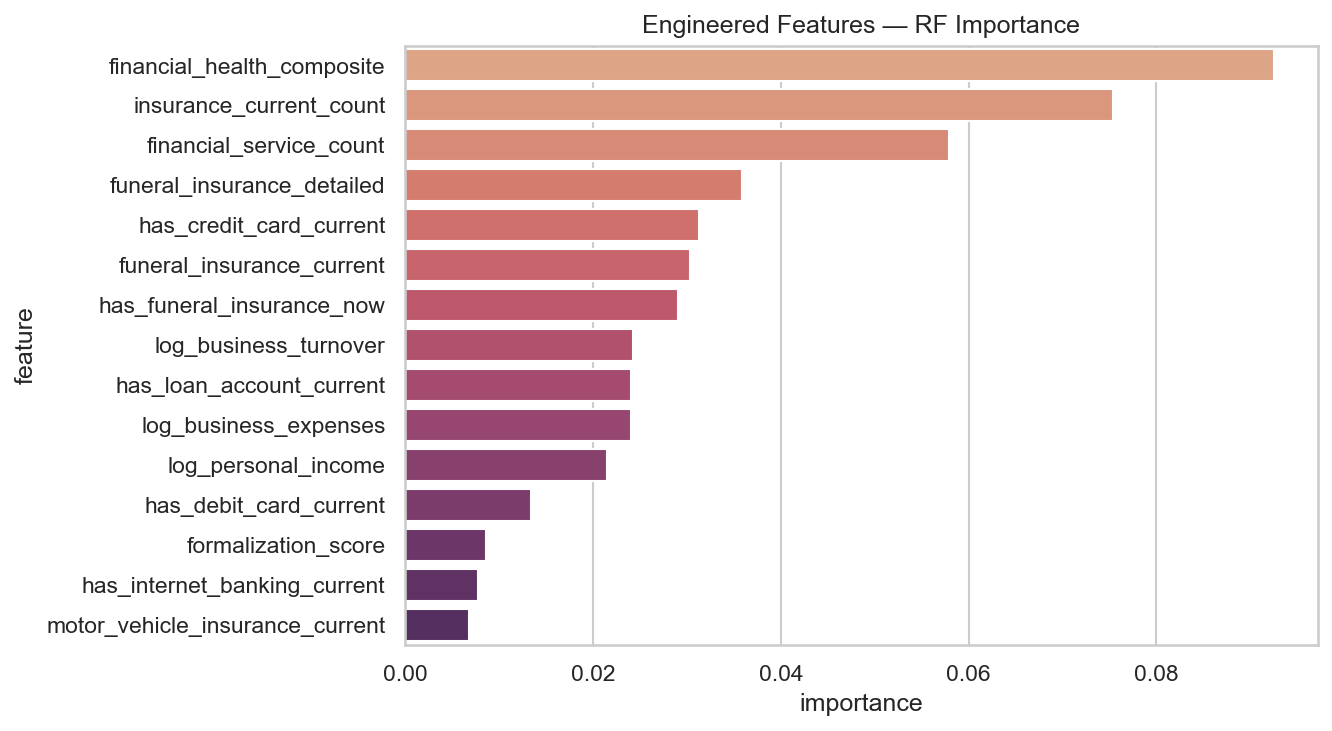

In [15]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_model, y)

rf_imp = (
    pd.DataFrame({"feature": X_model.columns, "importance": rf.feature_importances_})
    .sort_values("importance", ascending=False)
)
display(rf_imp.head(25))

if not figure_exists("15_random_forest_feature_importance_top30.png"):
    plt.figure(figsize=(10, 8))
    sns.barplot(data=rf_imp.head(30), y="feature", x="importance", palette="crest")
    plt.title("Random Forest Feature Importance (Top 30)")
save_figure("15_random_forest_feature_importance_top30.png")

rf_imp["is_engineered"] = rf_imp["feature"].isin(eng.columns)
eng_top = rf_imp[rf_imp["is_engineered"]].head(15)
if not figure_exists("16_engineered_features_rf_importance_top15.png"):
    plt.figure(figsize=(9, 5))
    sns.barplot(data=eng_top, y="feature", x="importance", palette="flare")
    plt.title("Engineered Features — RF Importance")
save_figure("16_engineered_features_rf_importance_top15.png")

## 16. LightGBM cross-validated performance

In [16]:
lgb_params = {
    "objective": "multiclass",
    "num_class": 3,
    "learning_rate": 0.05,
    "n_estimators": 400,
    "num_leaves": 31,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": RANDOM_STATE,
    "verbose": -1,
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_proba = np.zeros((len(X_model), 3))

for tr_idx, va_idx in skf.split(X_model, y):
    clf = lgb.LGBMClassifier(**lgb_params)
    clf.fit(X_model.iloc[tr_idx], y.iloc[tr_idx])
    oof_proba[va_idx] = clf.predict_proba(X_model.iloc[va_idx])

oof_pred = np.argmax(oof_proba, axis=1)
print("OOF Accuracy:", round(accuracy_score(y, oof_pred), 4))
print("OOF F1 macro:", round(f1_score(y, oof_pred, average="macro"), 4))
print("OOF Log loss:", round(log_loss(y, oof_proba), 4))
print(classification_report(y, oof_pred, target_names=CLASS_NAMES))

OOF Accuracy: 0.8743
OOF F1 macro: 0.8049
OOF Log loss: 0.3472
              precision    recall  f1-score   support

         Low       0.89      0.96      0.92      6280
      Medium       0.84      0.72      0.78      2868
        High       0.85      0.61      0.71       470

    accuracy                           0.87      9618
   macro avg       0.86      0.77      0.80      9618
weighted avg       0.87      0.87      0.87      9618



## 17. Confusion matrix (OOF)

Using cached figure: 17_confusion_matrix_lightgbm_oof.png


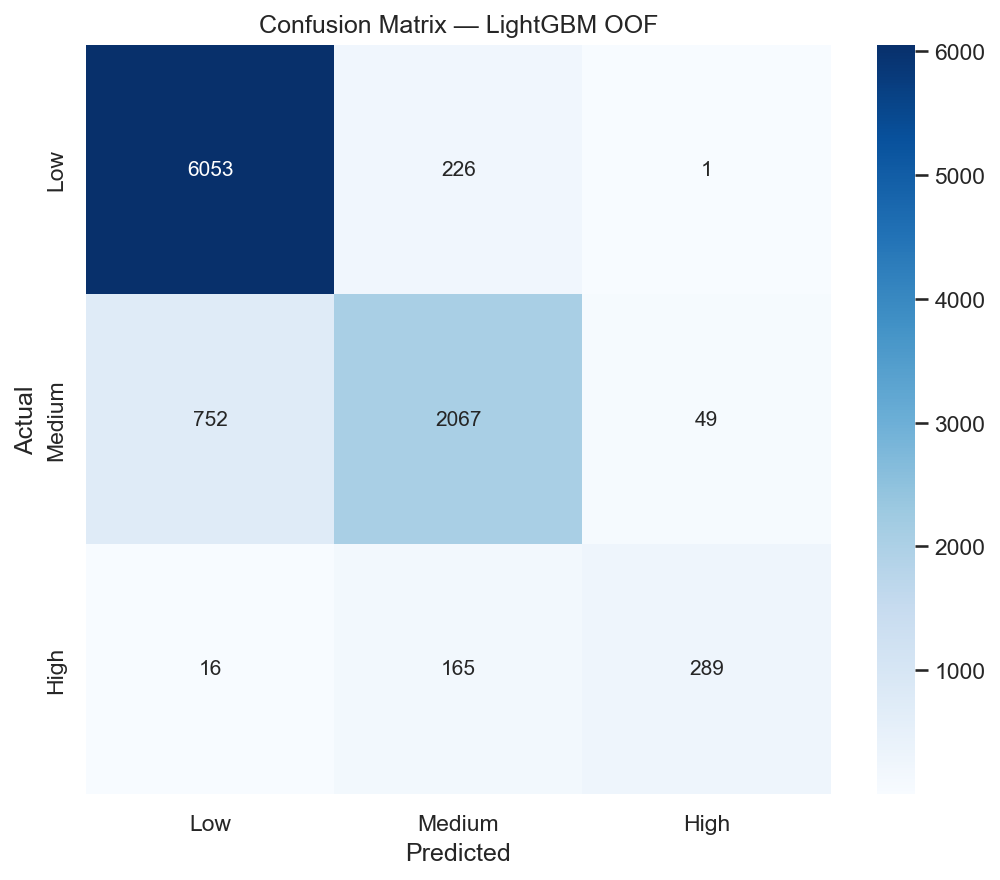

In [17]:
cm = confusion_matrix(y, oof_pred)

if not figure_exists("17_confusion_matrix_lightgbm_oof.png"):
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix — LightGBM OOF")
save_figure("17_confusion_matrix_lightgbm_oof.png")

## 18. ROC curves and AUC (one-vs-rest)

Using cached figure: 18_roc_curves_ovr_lightgbm_oof.png


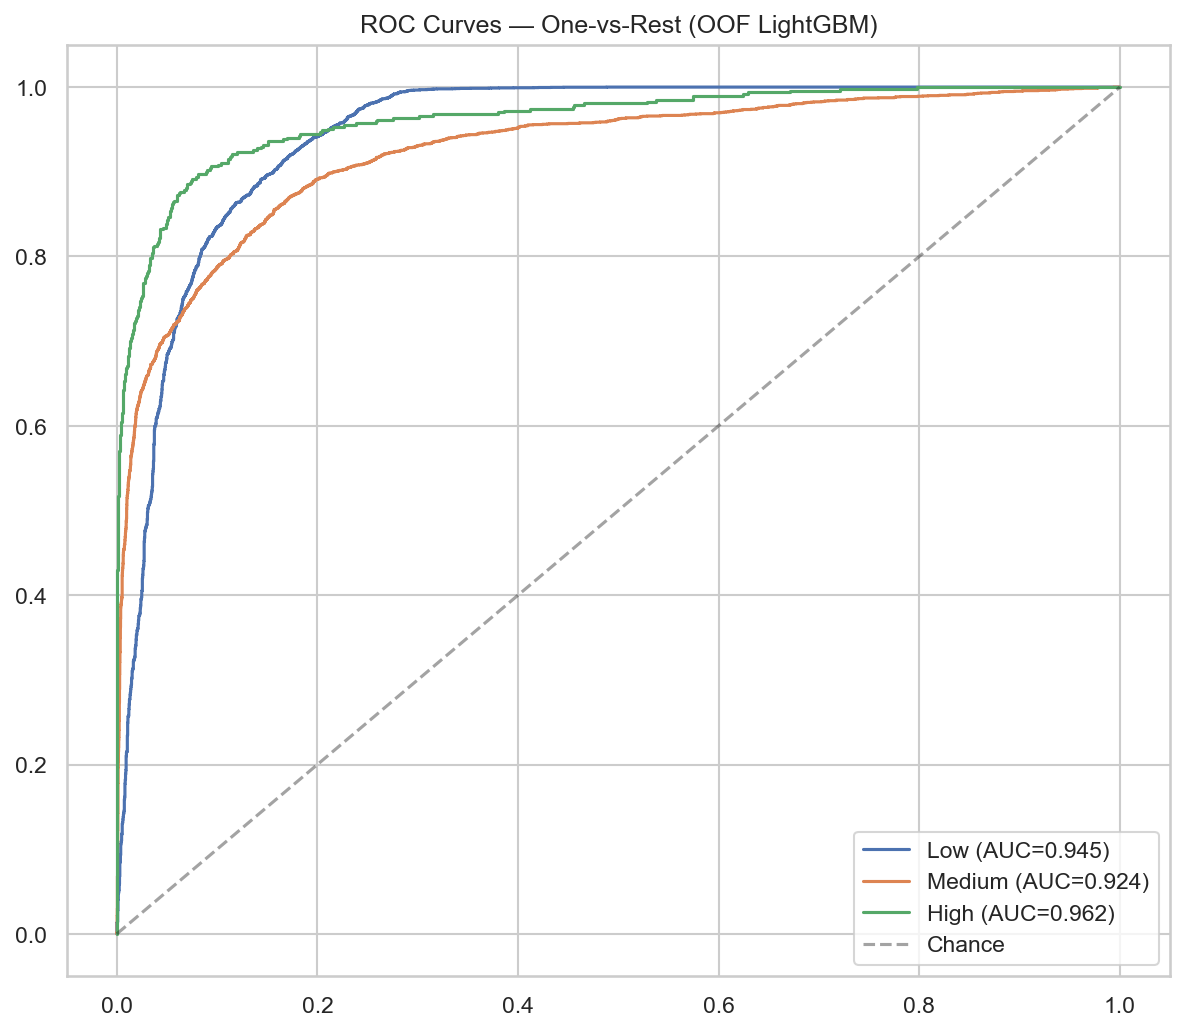

Per-class AUC: {'Low': 0.9451, 'Medium': 0.924, 'High': 0.9618}
Macro OVR AUC: 0.9437 | Weighted OVR AUC: 0.9397


In [18]:
y_bin = label_binarize(y, classes=[0, 1, 2])

if not figure_exists("18_roc_curves_ovr_lightgbm_oof.png"):
    fig, ax = plt.subplots(figsize=(8, 7))
    auc_scores = {}
    for i, cls in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], oof_proba[:, i])
        auc_scores[cls] = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{cls} (AUC={auc_scores[cls]:.3f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Chance")
    ax.set_title("ROC Curves — One-vs-Rest (OOF LightGBM)")
    ax.legend(loc="lower right")
save_figure("18_roc_curves_ovr_lightgbm_oof.png")

auc_scores = {}
for i, cls in enumerate(CLASS_NAMES):
    auc_scores[cls] = roc_auc_score(y_bin[:, i], oof_proba[:, i])

macro_auc = roc_auc_score(y_bin, oof_proba, multi_class="ovr", average="macro")
weighted_auc = roc_auc_score(y_bin, oof_proba, multi_class="ovr", average="weighted")
print("Per-class AUC:", {k: round(v, 4) for k, v in auc_scores.items()})
print(f"Macro OVR AUC: {macro_auc:.4f} | Weighted OVR AUC: {weighted_auc:.4f}")

## 19. LightGBM feature importance (gain)

,feature,importance
9,business_turnover,3404
1,owner_age,3236
7,personal_income,3227
8,business_expenses,3151
10,business_age_years,2198
57,financial_health_composite,1349
31,business_age_months,1054
27,has_loan_account,822
56,log_business_turnover,724
18,has_credit_card,700


Using cached figure: 19_lightgbm_feature_importance_top30.png


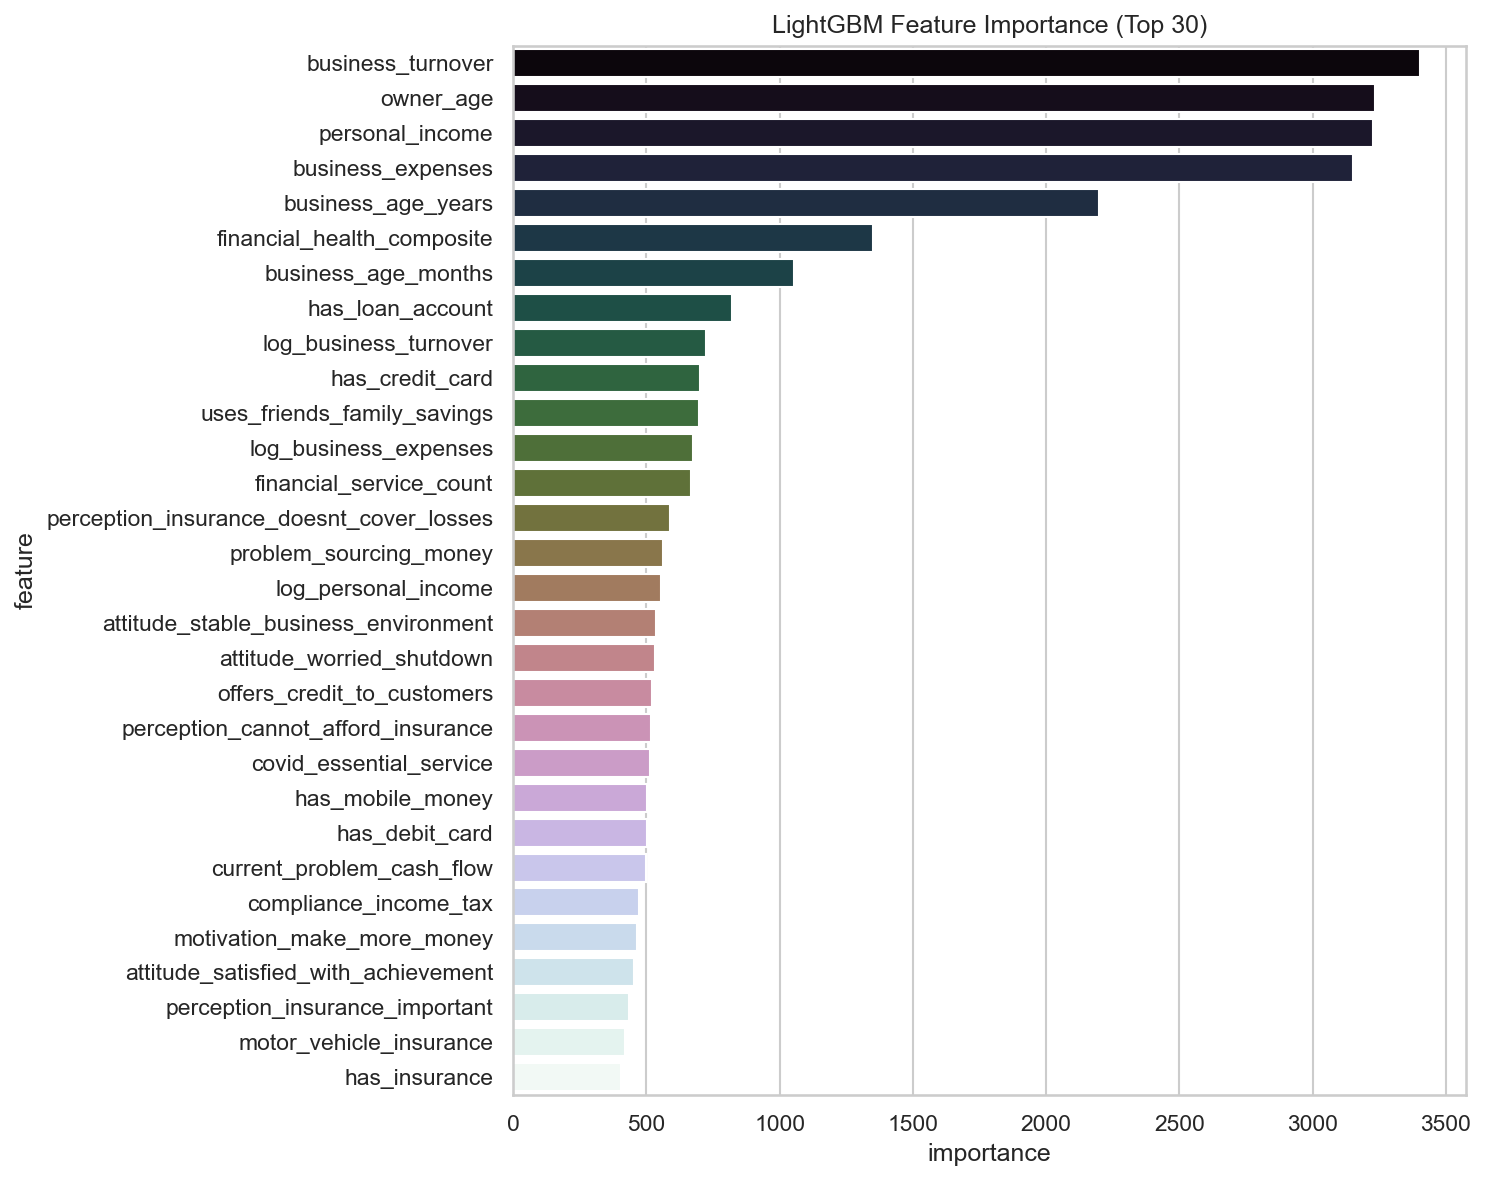

In [19]:
final_lgb = lgb.LGBMClassifier(**lgb_params)
final_lgb.fit(X_model, y)

lgb_imp = (
    pd.DataFrame({"feature": X_model.columns, "importance": final_lgb.feature_importances_})
    .sort_values("importance", ascending=False)
)
display(lgb_imp.head(25))

if not figure_exists("19_lightgbm_feature_importance_top30.png"):
    plt.figure(figsize=(10, 8))
    sns.barplot(data=lgb_imp.head(30), y="feature", x="importance", palette="cubehelix")
    plt.title("LightGBM Feature Importance (Top 30)")
save_figure("19_lightgbm_feature_importance_top30.png")

## 20. Decision parameters summary

In [20]:
if FINDINGS_PATH.exists():
    decision_summary = pd.read_csv(FINDINGS_PATH)
    print(f"Using cached findings: {FINDINGS_PATH.name}")
else:
    decision_summary = pd.DataFrame(
        [
            {
                "parameter": "Strongest categorical signal",
                "value": assoc_df.iloc[0]["feature"] if len(assoc_df) else "N/A",
                "metric": f"Cramér's V = {assoc_df.iloc[0]['cramers_v']:.3f}" if len(assoc_df) else "",
            },
            {
                "parameter": "Top MI feature",
                "value": mi_result.iloc[0]["feature"],
                "metric": f"MI = {mi_result.iloc[0]['mutual_information']:.4f}",
            },
            {
                "parameter": "Class imbalance ratio",
                "value": f"{imbalance_ratio:.2f}",
                "metric": "max class / min class count",
            },
            {
                "parameter": "OOF Accuracy (LGBM)",
                "value": f"{accuracy_score(y, oof_pred):.4f}",
                "metric": "5-fold stratified CV",
            },
            {
                "parameter": "OOF F1 macro",
                "value": f"{f1_score(y, oof_pred, average='macro'):.4f}",
                "metric": "primary ranking metric candidate",
            },
            {
                "parameter": "Macro ROC-AUC (OVR)",
                "value": f"{macro_auc:.4f}",
                "metric": "one-vs-rest on OOF probabilities",
            },
            {
                "parameter": "Recommended stratification",
                "value": "StratifiedKFold on Target",
                "metric": "handles 65/30/5% class mix",
            },
            {
                "parameter": "Key engineered blocks",
                "value": "insurance tiers, financial services, funeral insurance, country, formalization",
                "metric": "see model v3 notebook",
            },
        ]
    )
    decision_summary.to_csv(FINDINGS_PATH, index=False, mode="w")
    print(f"Saved findings: {FINDINGS_PATH.name}")

display(decision_summary)

saved = {p.name for p in FIGURES.glob("*.png")}
missing = [n for n in EXPECTED_FIGURES if n not in saved]
print(f"\nFigures on disk: {len(saved)}/{len(EXPECTED_FIGURES)}")
if missing:
    print("  Still need to generate:", ", ".join(missing))

Using cached findings: decision_parameters_summary.csv


,parameter,value,metric
0,Strongest categorical signal,funeral_insurance,Cramér's V = 0.546
1,Top MI feature,funeral_insurance,MI = 0.2232
2,Class imbalance ratio,13.36,max class / min class count
3,OOF Accuracy (LGBM),0.8743,5-fold stratified CV
4,OOF F1 macro,0.8049,primary ranking metric candidate
5,Macro ROC-AUC (OVR),0.9437,one-vs-rest on OOF probabilities
6,Recommended stratification,StratifiedKFold on Target,handles 65/30/5% class mix
7,Key engineered blocks,"insurance tiers, financial services, funeral i...",see model v3 notebook



Figures on disk: 19/19


## 21. Figure gallery

Static previews from `figures/`. These render in the notebook when the PNG files exist (no need to re-plot).

### Missing value pattern

![](figures/01_missing_value_pattern_sample500.png)

### Target distribution

![](figures/02_target_distribution_counts_and_percent.png)

### Target by country

![](figures/03_target_distribution_by_country_stacked.png)

### Numeric distributions

![](figures/04_numeric_feature_distributions_histograms.png)

### Numeric features by target

![](figures/05_numeric_boxplots_by_target.png)

### Correlation with target

![](figures/06_numeric_correlation_with_target.png)

### Numeric correlation heatmap

![](figures/07_numeric_correlation_heatmap.png)

### Cramér's V (top categoricals)

![](figures/08_top_categorical_cramers_v_with_target.png)

### Mutual information

![](figures/09_mutual_information_top25.png)

### Top categoricals vs target

![](figures/10_top_categorical_target_composition_stacked.png)

### Insurance adoption tiers

![](figures/11_insurance_adoption_tier_vs_target.png)

### Financial services tiers

![](figures/12_financial_services_adoption_tier_vs_target.png)

### Engineered feature correlations

![](figures/13_engineered_features_correlation_heatmap.png)

### Engineered features by target

![](figures/14_engineered_features_boxplots_by_target.png)

### Random Forest importance

![](figures/15_random_forest_feature_importance_top30.png)

### Engineered RF importance

![](figures/16_engineered_features_rf_importance_top15.png)

### Confusion matrix (LightGBM OOF)

![](figures/17_confusion_matrix_lightgbm_oof.png)

### ROC curves (one-vs-rest)

![](figures/18_roc_curves_ovr_lightgbm_oof.png)

### LightGBM importance

![](figures/19_lightgbm_feature_importance_top30.png)

